In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [70]:
import spacy
from spacy.training.example import Example
import random

In [71]:
df=pd.read_csv('AyurGenixAI_Dataset.csv')

In [72]:
df.head()

,Disease,Hindi Name,Marathi Name,Symptoms,Diagnosis & Tests,Symptom Severity,Duration of Treatment,Medical History,Current Medications,Risk Factors,...,Formulation,Doshas,Constitution/Prakriti,Diet and Lifestyle Recommendations,Yoga & Physical Therapy,Medical Intervention,Prevention,Prognosis,Complications,Patient Recommendations
0,Cough,खांसी,खोकला,"Sore throat, chest congestion","Chest X-ray, Blood tests, Sputum analysis",Mild to Moderate,1-2 weeks,"Asthma, Respiratory Issues","Cough syrup, Inhalers","Viral infections, Smoking",...,"Ginger (2g), Honey (1 tsp)","Vata, Kapha",Vata-Kapha,Avoid cold foods; stay hydrated; consume warm ...,"Anulom Vilom, Pranayama","Cough syrup, Antibiotics",Avoid irritants,Usually mild,"Bronchitis, Pneumonia","Stay hydrated, rest"
1,Diabetes,मधुमेह,मधुमेह,"Frequent urination, fatigue","Blood sugar test, HbA1c test",Moderate to High,Lifetime management,Family history of diabetes,"Insulin, Metformin","Obesity, Genetics, Age > 40",...,Fenugreek (3g daily),"Pitta, Kapha",Kapha,Avoid sugary foods; focus on low-GI foods; reg...,"Surya Namaskar, Pranayama","Insulin, Oral meds",Regular exercise,"Chronic, manageable","Retinopathy, Kidney disease","Healthy diet, exercise"
2,Hypertension,उच्च रक्तचाप,उच्च रक्तदाब,"High blood pressure, stress",Blood pressure measurement,High,Lifetime management,"Heart disease, Stroke","Beta-blockers, Diuretics","Family history, Obesity, Age",...,Ashwagandha (5g daily),"Pitta, Vata",Pitta,Reduce salt; practice yoga and meditation; avo...,"Surya Namaskar, Meditation",Antihypertensive meds,Salt restriction,Chronic,"Heart failure, Stroke","Limit salt, exercise"
3,Migraine,माइग्रेन,डोकेदुखी,"Severe headache, nausea","CT scan, MRI, Neurological exam",Moderate to Severe,3-4 days for relief,Family history of migraines,Pain relievers (NSAIDs),"Stress, Hormonal changes",...,Peppermint (2 drops in water),"Pitta, Vata",Pitta-Vata,Maintain regular meal times; avoid bright ligh...,"Anulom Vilom, Pranayama","Pain relievers, Botox",Stress management,Variable,"Stroke, Anxiety, Depression","Sleep, avoid triggers"
4,Arthritis,गठिया,आर्थरायटीस,"Joint pain, swelling","X-ray, MRI, Blood tests (RA factor)",Moderate to Severe,Variable,"Joint pain, Obesity",Pain relievers (NSAIDs),"Age, Joint overuse, Genetics",...,"Turmeric (1/2 tsp), Milk (200ml)","Vata, Kapha",Vata,Consume anti-inflammatory foods; stay active; ...,"Yoga for flexibility, Strength","NSAIDs, Steroids",Weight management,Chronic,"Joint deformity, Mobility issues","Exercise, joint care"


In [73]:
df.isnull().sum()

Disease                                 0
Hindi Name                              0
Marathi Name                            0
Symptoms                                0
Diagnosis & Tests                       0
Symptom Severity                        0
Duration of Treatment                   0
Medical History                         1
Current Medications                     0
Risk Factors                            0
Environmental Factors                   0
Sleep Patterns                          0
Stress Levels                           0
Physical Activity Levels                0
Family History                          1
Dietary Habits                          0
Allergies (Food/Env)                  350
Seasonal Variation                      0
Age Group                               0
Gender                                  0
Occupation and Lifestyle                0
Cultural Preferences                    0
Herbal/Alternative Remedies            15
Ayurvedic Herbs                   

In [74]:
df = df.fillna("Unknown")

In [75]:
df.isnull().sum()

Disease                               0
Hindi Name                            0
Marathi Name                          0
Symptoms                              0
Diagnosis & Tests                     0
Symptom Severity                      0
Duration of Treatment                 0
Medical History                       0
Current Medications                   0
Risk Factors                          0
Environmental Factors                 0
Sleep Patterns                        0
Stress Levels                         0
Physical Activity Levels              0
Family History                        0
Dietary Habits                        0
Allergies (Food/Env)                  0
Seasonal Variation                    0
Age Group                             0
Gender                                0
Occupation and Lifestyle              0
Cultural Preferences                  0
Herbal/Alternative Remedies           0
Ayurvedic Herbs                       0
Formulation                           0


In [76]:
df = df.drop([
    "Hindi Name",
    "Marathi Name",
    "Seasonal Variation",
    "Occupation and Lifestyle",
    "Physical Activity Levels",
    "Dietary Habits",
    "Cultural Preferences",
    "Yoga & Physical Therapy",
    "Patient Recommendations",
    "Prognosis",
    "Prevention",
    "Diet and Lifestyle Recommendations"
], axis=1)

In [77]:
df.head()

,Disease,Symptoms,Diagnosis & Tests,Symptom Severity,Duration of Treatment,Medical History,Current Medications,Risk Factors,Environmental Factors,Sleep Patterns,...,Allergies (Food/Env),Age Group,Gender,Herbal/Alternative Remedies,Ayurvedic Herbs,Formulation,Doshas,Constitution/Prakriti,Medical Intervention,Complications
0,Cough,"Sore throat, chest congestion","Chest X-ray, Blood tests, Sputum analysis",Mild to Moderate,1-2 weeks,"Asthma, Respiratory Issues","Cough syrup, Inhalers","Viral infections, Smoking","Dry, Cold Air, Dusty Air",Irregular Sleep,...,"Dust, Pollen",All ages,All genders,"Ginger, Honey","Tulsi, Ashwagandha","Ginger (2g), Honey (1 tsp)","Vata, Kapha",Vata-Kapha,"Cough syrup, Antibiotics","Bronchitis, Pneumonia"
1,Diabetes,"Frequent urination, fatigue","Blood sugar test, HbA1c test",Moderate to High,Lifetime management,Family history of diabetes,"Insulin, Metformin","Obesity, Genetics, Age > 40","High Sugar, Sedentary Life",Poor Sleep,...,"Gluten, Dairy",30-60 years,Both genders,"Cinnamon, Bitter melon","Jamun, Gudmar",Fenugreek (3g daily),"Pitta, Kapha",Kapha,"Insulin, Oral meds","Retinopathy, Kidney disease"
2,Hypertension,"High blood pressure, stress",Blood pressure measurement,High,Lifetime management,"Heart disease, Stroke","Beta-blockers, Diuretics","Family history, Obesity, Age","Hot weather, Salt intake",Poor Sleep,...,Unknown,40-70 years,Both genders,"Garlic, Hibiscus tea","Ashwagandha, Arjuna",Ashwagandha (5g daily),"Pitta, Vata",Pitta,Antihypertensive meds,"Heart failure, Stroke"
3,Migraine,"Severe headache, nausea","CT scan, MRI, Neurological exam",Moderate to Severe,3-4 days for relief,Family history of migraines,Pain relievers (NSAIDs),"Stress, Hormonal changes","Bright lights, Loud sounds",Irregular Sleep,...,Unknown,20-50 years,Mostly Female,"Peppermint, Lavender oil","Brahmi, Jatamansi",Peppermint (2 drops in water),"Pitta, Vata",Pitta-Vata,"Pain relievers, Botox","Stroke, Anxiety, Depression"
4,Arthritis,"Joint pain, swelling","X-ray, MRI, Blood tests (RA factor)",Moderate to Severe,Variable,"Joint pain, Obesity",Pain relievers (NSAIDs),"Age, Joint overuse, Genetics","Cold, Damp weather",Poor Sleep,...,"Pollen, Dust",40+ years,Both genders,"Turmeric, Ginger","Ashwagandha, Guggul","Turmeric (1/2 tsp), Milk (200ml)","Vata, Kapha",Vata,"NSAIDs, Steroids","Joint deformity, Mobility issues"


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Disease                      446 non-null    object
 1   Symptoms                     446 non-null    object
 2   Diagnosis & Tests            446 non-null    object
 3   Symptom Severity             446 non-null    object
 4   Duration of Treatment        446 non-null    object
 5   Medical History              446 non-null    object
 6   Current Medications          446 non-null    object
 7   Risk Factors                 446 non-null    object
 8   Environmental Factors        446 non-null    object
 9   Sleep Patterns               446 non-null    object
 10  Stress Levels                446 non-null    object
 11  Family History               446 non-null    object
 12  Allergies (Food/Env)         446 non-null    object
 13  Age Group                    446 no

In [79]:
df.describe()

,Disease,Symptoms,Diagnosis & Tests,Symptom Severity,Duration of Treatment,Medical History,Current Medications,Risk Factors,Environmental Factors,Sleep Patterns,...,Allergies (Food/Env),Age Group,Gender,Herbal/Alternative Remedies,Ayurvedic Herbs,Formulation,Doshas,Constitution/Prakriti,Medical Intervention,Complications
count,446,446,446,446,446,446,446,446,446,446,...,446,446,446,446,446,446,446,446,446,446
unique,367,429,310,7,59,372,287,330,345,8,...,53,55,7,121,75,210,9,12,293,382
top,Asthma,"Swollen lymph nodes, fever, night sweats, weig...","Genetic Testing, Physical Exam",Severe,Lifelong,Genetic metabolic disorders,Symptom-specific therapy,"Genetic Mutations, Family History","Genetic, Environmental factors",Irregular sleep,...,Unknown,Adults,Both genders,None specific,None specific,"Neem leaves (5-6), Water (as needed)",Pitta,Vata-Prakriti,Antibiotics,"Cirrhosis, Liver Cancer"
freq,4,3,16,246,192,7,19,38,16,331,...,350,97,417,276,256,24,132,94,18,6


In [80]:
df.shape

(446, 22)

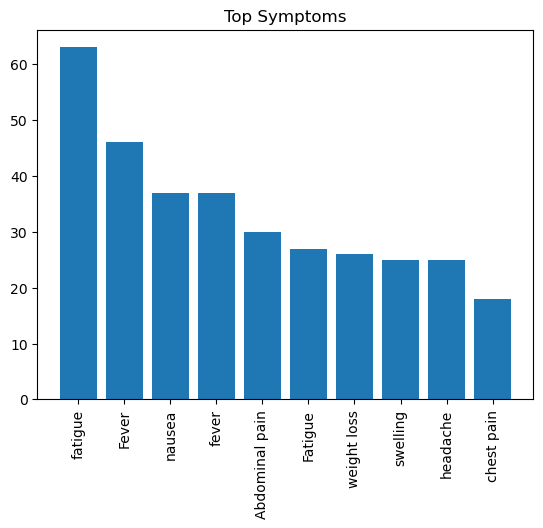

In [81]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("AyurGenixAI_Dataset.csv")

all_symptoms = []

for symptoms in df["Symptoms"].dropna():
    all_symptoms.extend([s.strip() for s in symptoms.split(",")])

counts = Counter(all_symptoms)

top = dict(counts.most_common(10))

plt.bar(top.keys(), top.values())
plt.xticks(rotation=90)
plt.title("Top Symptoms")
plt.show()

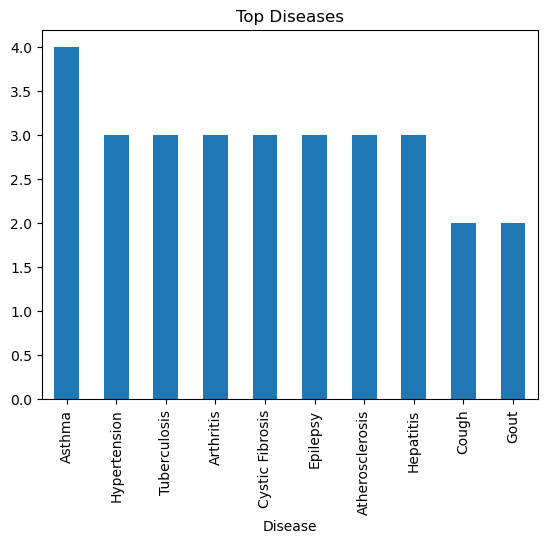

In [82]:
disease_counts = df["Disease"].value_counts().head(10)

disease_counts.plot(kind="bar")
plt.title("Top Diseases")
plt.show()

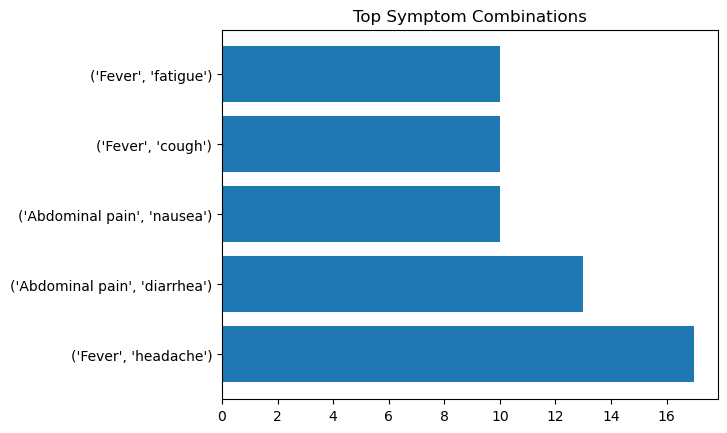

In [83]:
from itertools import combinations

pairs = []

for symptoms in df["Symptoms"].dropna():
    s_list = [s.strip() for s in symptoms.split(",")]
    pairs.extend(combinations(s_list, 2))

pair_counts = Counter(pairs)

top_pairs = dict(pair_counts.most_common(5))

plt.barh([str(k) for k in top_pairs.keys()], top_pairs.values())
plt.title("Top Symptom Combinations")
plt.show()

In [84]:
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    text = text.lower()   
    doc = nlp(text)
    tokens = [token.text for token in doc]
    return tokens

print(preprocess("I have Fever and headache!!"))

['i', 'have', 'fever', 'and', 'headache', '!', '!']


In [85]:
#implementing pipeline
import pandas as pd
import re
import unicodedata
from collections import Counter

df = pd.read_csv("AyurGenixAI_Dataset.csv")

texts = df["Symptoms"].dropna().astype(str).tolist()

In [86]:
def unicode_normalize(text):
    return unicodedata.normalize('NFKC', text)

In [87]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [88]:
def sentence_split(text):
    return re.split(r'[.,;]', text)

In [89]:
def tokenize(sentence):
    return sentence.split()

In [90]:
synonym_dict = {
    "feverish": "fever",
    "high temperature": "fever",
    "head pain": "headache",
    "stomach ache": "abdominal pain"
}

def normalize_synonyms(tokens):
    return [synonym_dict.get(token, token) for token in tokens]

In [91]:
#annotation
def bio_tagging(tokens, symptom_list):
    tags = []
    for token in tokens:
        if token in symptom_list:
            tags.append("B-SYMPTOM")
        else:
            tags.append("O")
    return tags

In [92]:
#applying pipeline
processed_data = []

for text in texts:
    text = unicode_normalize(text)
    text = clean_text(text)
    
    sentences = sentence_split(text)
    
    for sent in sentences:
        tokens = tokenize(sent)
        tokens = normalize_synonyms(tokens)
        
        symptom_list = [s.strip() for s in text.split(",")]
        
        tags = bio_tagging(tokens, symptom_list)
        
        processed_data.append((tokens, tags))

In [93]:
#building vocublary
word_counts = Counter()

for tokens, _ in processed_data:
    word_counts.update(tokens)

vocab = {word: i+1 for i, (word, _) in enumerate(word_counts.items())}

print(list(vocab.items())[:10])

[('sore', 1), ('throat', 2), ('chest', 3), ('congestion', 4), ('frequent', 5), ('urination', 6), ('fatigue', 7), ('high', 8), ('blood', 9), ('pressure', 10)]


In [94]:
#convert to sequence
def encode_tokens(tokens, vocab):
    return [vocab.get(token, 0) for token in tokens]

In [95]:
#masking and padding
max_len = 10

def pad_sequence(seq, max_len):
    padded = seq[:max_len] + [0]*(max_len - len(seq))
    mask = [1 if i < len(seq) else 0 for i in range(max_len)]
    return padded, mask

X = []
masks = []

for tokens, _ in processed_data:
    encoded = encode_tokens(tokens, vocab)
    padded, mask = pad_sequence(encoded, max_len)
    
    X.append(padded)
    masks.append(mask)

In [96]:
print("Sample Tokens:", processed_data[0][0])
print("Sample Tags:", processed_data[0][1])
print("Encoded:", X[0])
print("Mask:", masks[0])

Sample Tokens: ['sore', 'throat']
Sample Tags: ['O', 'O']
Encoded: [1, 2, 0, 0, 0, 0, 0, 0, 0, 0]
Mask: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [97]:
test_text = "I have severe headache and fever"

text = unicode_normalize(test_text)
text = clean_text(text)

tokens = tokenize(text)
tokens = normalize_synonyms(tokens)

symptom_list = ["headache", "fever"]

tags = bio_tagging(tokens, symptom_list)

encoded = encode_tokens(tokens, vocab)
padded, mask = pad_sequence(encoded, max_len)

print("Tokens:", tokens)
print("Tags:", tags)
print("Encoded:", padded)
print("Mask:", mask)

Tokens: ['i', 'have', 'severe', 'headache', 'and', 'fever']
Tags: ['O', 'O', 'O', 'B-SYMPTOM', 'O', 'B-SYMPTOM']
Encoded: [0, 0, 12, 13, 152, 22, 0, 0, 0, 0]
Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]


In [98]:
import pandas as pd
import json

df = pd.read_csv("AyurGenixAI_Dataset.csv")

output = []

for _, row in df.iterrows():
    if pd.isna(row["Symptoms"]):
        continue
    
    symptoms = [s.strip().lower() for s in str(row["Symptoms"]).split(",")]
    
    # Create sentence
    text = "I have " + " and ".join(symptoms)
    
    labels = []
    start = 0
    
    for sym in symptoms:
        start = text.find(sym, start)
        end = start + len(sym)
        labels.append([start, end, "SYMPTOM"])
    
    output.append({
        "text": text,
        "labels": labels
    })

# for doccano
with open("annotations.jsonl", "w") as f:
    for item in output:
        f.write(json.dumps(item) + "\n")

print(" Annotation file created: annotations.jsonl")

 Annotation file created: annotations.jsonl


In [99]:
{"text": "I have fever and cough", "labels": [[7, 12, "SYMPTOM"], [17, 22, "SYMPTOM"]]}
{"text": "I have headache and nausea", "labels": [[7, 15, "SYMPTOM"], [20, 26, "SYMPTOM"]]}

{'text': 'I have headache and nausea',
 'labels': [[7, 15, 'SYMPTOM'], [20, 26, 'SYMPTOM']]}

In [100]:
disease = str(row["Disease"]).lower()
# Add disease entity
d_start = text.find(disease)
if d_start != -1:
    labels.append([d_start, d_start + len(disease), "DISEASE"])

In [101]:
#training and testing part
import json

TRAIN_DATA = []

with open("annotations.jsonl", "r") as f:
    for line in f:
        item = json.loads(line)
        text = item["text"]
        entities = item["labels"]
        
        TRAIN_DATA.append((text, {"entities": entities}))

print(TRAIN_DATA[:2])

[('I have sore throat and chest congestion', {'entities': [[7, 18, 'SYMPTOM'], [23, 39, 'SYMPTOM']]}), ('I have frequent urination and fatigue', {'entities': [[7, 25, 'SYMPTOM'], [30, 37, 'SYMPTOM']]})]


In [102]:
#creating model
import spacy

nlp = spacy.blank("en")  
ner = nlp.add_pipe("ner")

In [103]:
#adding labels
labels = ["SYMPTOM", "DISEASE"]

for label in labels:
    ner.add_label(label)

In [104]:
#training model
from spacy.training.example import Example
import random

optimizer = nlp.begin_training()

for epoch in range(20):
    random.shuffle(TRAIN_DATA)
    losses = {}
    
    for text, annotations in TRAIN_DATA:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)
        nlp.update([example], losses=losses)
    
    print(f"Epoch {epoch+1}, Loss: {losses}")

Epoch 1, Loss: {'ner': np.float32(243.32695)}
Epoch 2, Loss: {'ner': np.float32(48.57717)}
Epoch 3, Loss: {'ner': np.float32(47.855827)}
Epoch 4, Loss: {'ner': np.float32(23.839264)}
Epoch 5, Loss: {'ner': np.float32(28.205044)}
Epoch 6, Loss: {'ner': np.float32(26.053804)}
Epoch 7, Loss: {'ner': np.float32(34.812515)}
Epoch 8, Loss: {'ner': np.float32(14.574074)}
Epoch 9, Loss: {'ner': np.float32(14.97014)}
Epoch 10, Loss: {'ner': np.float32(26.853287)}
Epoch 11, Loss: {'ner': np.float32(14.645309)}
Epoch 12, Loss: {'ner': np.float32(23.514755)}
Epoch 13, Loss: {'ner': np.float32(19.127731)}
Epoch 14, Loss: {'ner': np.float32(24.46359)}
Epoch 15, Loss: {'ner': np.float32(8.319787)}
Epoch 16, Loss: {'ner': np.float32(18.15538)}
Epoch 17, Loss: {'ner': np.float32(24.367414)}
Epoch 18, Loss: {'ner': np.float32(7.6816463)}
Epoch 19, Loss: {'ner': np.float32(10.551122)}
Epoch 20, Loss: {'ner': np.float32(12.884022)}


In [105]:
from spacy.scorer import Scorer
from spacy.training.example import Example

scorer = Scorer()

examples = []

for text, annotations in TRAIN_DATA:
    doc = nlp(text)  
    example = Example.from_dict(doc, annotations)
    examples.append(example)

scores = scorer.score(examples)

print("Precision:", scores["ents_p"])
print("Recall:", scores["ents_r"])
print("F1-score:", scores["ents_f"])

Precision: 0.9986043265875785
Recall: 0.997907949790795
F1-score: 0.9982560167422393


In [106]:
train_size = int(0.8 * len(TRAIN_DATA))

train_data = TRAIN_DATA[:train_size]
test_data = TRAIN_DATA[train_size:]

In [107]:
examples = []

for text, annotations in test_data:
    doc = nlp(text)
    example = Example.from_dict(doc, annotations)
    examples.append(example)

scores = scorer.score(examples)
print(scores)

{'token_acc': 1.0, 'token_p': 1.0, 'token_r': 1.0, 'token_f': 1.0, 'sents_p': None, 'sents_r': None, 'sents_f': None, 'tag_acc': None, 'pos_acc': None, 'morph_acc': None, 'morph_micro_p': None, 'morph_micro_r': None, 'morph_micro_f': None, 'morph_per_feat': None, 'dep_uas': None, 'dep_las': None, 'dep_las_per_type': None, 'ents_p': 1.0, 'ents_r': 1.0, 'ents_f': 1.0, 'ents_per_type': {'SYMPTOM': {'p': 1.0, 'r': 1.0, 'f': 1.0}}, 'cats_score': 0.0, 'cats_score_desc': 'macro F', 'cats_micro_p': 0.0, 'cats_micro_r': 0.0, 'cats_micro_f': 0.0, 'cats_macro_p': 0.0, 'cats_macro_r': 0.0, 'cats_macro_f': 0.0, 'cats_macro_auc': 0.0, 'cats_f_per_type': {}, 'cats_auc_per_type': {}}


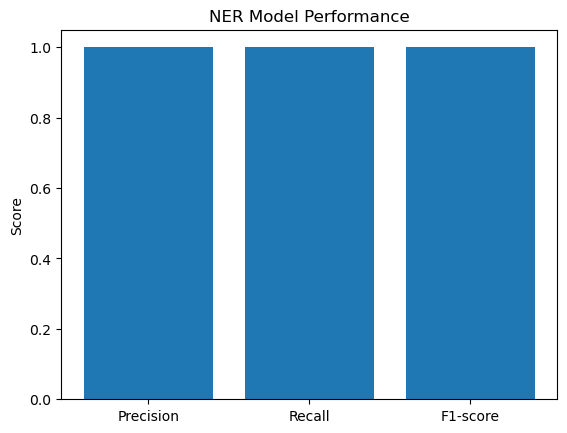

In [108]:
import matplotlib.pyplot as plt

precision = scores["ents_p"]
recall = scores["ents_r"]
f1 = scores["ents_f"]

metrics = ["Precision", "Recall", "F1-score"]
values = [precision, recall, f1]

plt.bar(metrics, values)
plt.title("NER Model Performance")
plt.ylabel("Score")
plt.show()

In [109]:
text = "I have fever and cough due to flu"

doc = nlp(text)

entities = [(ent.text, ent.label_) for ent in doc.ents]
print(entities)

[('fever', 'SYMPTOM'), ('cough due to flu', 'SYMPTOM')]


In [110]:
symptoms = [e[0] for e in entities if e[1] == "SYMPTOM"]
diseases = [e[0] for e in entities if e[1] == "DISEASE"]

triples = []

for s in symptoms:
    for d in diseases:
        triples.append((s, "indicates", d))

print(triples)

[]


In [111]:
import pandas as pd

df = pd.read_csv("AyurGenixAI_Dataset.csv")

triples = []

for _, row in df.iterrows():
    if pd.isna(row["Symptoms"]) or pd.isna(row["Disease"]):
        continue
    
    disease = row["Disease"].lower()
    symptoms = [s.strip().lower() for s in row["Symptoms"].split(",")]
    
    for s in symptoms:
        triples.append((s, "indicates", disease))

In [112]:
#implementing knowlegdge base
import pandas as pd

df = pd.read_csv("AyurGenixAI_Dataset.csv")

knowledge = []

for _, row in df.iterrows():
    if pd.isna(row["Symptoms"]) or pd.isna(row["Disease"]):
        continue
    
    disease = row["Disease"].lower()
    symptoms = [s.strip().lower() for s in row["Symptoms"].split(",")]
    
    for s in symptoms:
        knowledge.append((s, "indicates", disease))

# Print some knowledge
for k in knowledge[:10]:
    print(k)

('sore throat', 'indicates', 'cough')
('chest congestion', 'indicates', 'cough')
('frequent urination', 'indicates', 'diabetes')
('fatigue', 'indicates', 'diabetes')
('high blood pressure', 'indicates', 'hypertension')
('stress', 'indicates', 'hypertension')
('severe headache', 'indicates', 'migraine')
('nausea', 'indicates', 'migraine')
('joint pain', 'indicates', 'arthritis')
('swelling', 'indicates', 'arthritis')


In [113]:
kg = {}

for s, _, d in knowledge:
    if d not in kg:
        kg[d] = []
    kg[d].append(s)

print(kg)

{'cough': ['sore throat', 'chest congestion', 'sore throat', 'dry or wet cough'], 'diabetes': ['frequent urination', 'fatigue', 'frequent urination', 'excessive thirst', 'fatigue'], 'hypertension': ['high blood pressure', 'stress', 'high blood pressure', 'headaches', 'dizziness', 'high blood pressure', 'dizziness', 'headaches', 'shortness of breath'], 'migraine': ['severe headache', 'nausea', 'severe headache', 'nausea', 'sensitivity to light/sound'], 'arthritis': ['joint pain', 'swelling', 'joint pain', 'stiffness', 'swelling', 'vision loss', 'difficulty focusing'], 'common cold': ['runny nose', 'sneezing', 'mild fever'], 'indigestion': ['bloating', 'abdominal discomfort', 'bloating', 'nausea', 'discomfort after eating'], 'asthma': ['wheezing', 'shortness of breath', 'wheezing', 'shortness of breath', 'chest tightness', 'pain', 'swelling', 'difficulty moving', 'difficulty breathing', 'wheezing', 'coughing'], 'constipation': ['hard stools', 'infrequent bowel movement', 'irregular bowel

In [114]:
def ner_output(text, nlp_model):
    doc = nlp_model(text)
    
    print("\n NER Output:")
    for ent in doc.ents:
        print(f"{ent.text} -> {ent.label_}")

In [115]:
ner_output("I have fever and headache", nlp)


 NER Output:
fever -> SYMPTOM
headache -> SYMPTOM


In [116]:
from spacy import displacy

text = "I have severe headache and fever since yesterday"

doc = nlp(text)

displacy.render(doc, style="ent", jupyter=True)

In [117]:
from spacy import displacy

text = "The patient was diagnosed with malaria and was treated with chloroquine for fever"

doc = nlp(text)

displacy.render(doc, style="ent", jupyter=True)

In [1]:
import warnings
warnings.filterwarnings('ignore')
 

In [2]:
import pandas as pd
import json
 
df = pd.read_csv("AyurGenixAI_Dataset.csv")

In [3]:
DOSHA_TERMS = [
    "vata", "pitta", "kapha", "tridosha", "vata dosha",
    "pitta dosha", "kapha dosha", "vata-pitta", "pitta-kapha",
    "vata-kapha", "prakriti", "vikriti"
]
 
PROCEDURE_TERMS = [
    "panchakarma", "vamana", "virechana", "basti", "nasya", "raktamokshana",
    "shirodhara", "abhyanga", "swedana", "udvartana", "pinda sweda",
    "kati basti", "janu basti", "greeva basti", "navarakizhi",
    "elakizhi", "pizhichil", "thalapothichil"
]
 
MEDICINE_TERMS = [
    "ashwagandha", "triphala", "brahmi", "neem", "turmeric", "ginger",
    "amla", "shatavari", "guduchi", "tulsi", "haritaki", "bibhitaki",
    "amalaki", "guggul", "shilajit", "punarnava", "manjistha", "licorice",
    "bala", "vidari", "pippali", "chitrak", "mustard", "sesame",
    "castor oil", "ghee", "trikatu", "dashamoola", "chyawanprash",
    "mahasudarshana churna", "arogyavardhini vati"
]
 
DISEASE_TERMS = [
    "jwara", "fever", "cough", "prameha", "diabetes", "kushtha",
    "skin disease", "amavata", "rheumatoid arthritis", "sandhivata",
    "osteoarthritis", "vata roga", "hridaya roga", "heart disease",
    "pandu", "anemia", "arsha", "piles", "atisara", "diarrhea",
    "grahani", "ibs", "shwasa", "asthma", "rajayakshma", "tuberculosis",
    "visarpa", "erysipelas", "gulma", "abdominal tumor", "mutrakriccha",
    "uti", "timira", "eye disease", "kamala", "jaundice"
]
 
SYMPTOM_TERMS = [
    "fever", "headache", "nausea", "vomiting", "fatigue", "cough",
    "cold", "body pain", "joint pain", "swelling", "redness",
    "itching", "burning sensation", "weight loss", "weight gain",
    "loss of appetite", "insomnia", "anxiety", "depression",
    "palpitation", "breathlessness", "constipation", "diarrhea",
    "bloating", "indigestion", "acidity", "skin rash", "dryness",
    "oiliness", "hair fall", "back pain", "knee pain", "weakness"
]
 
def find_entities(text, entity_list, label):
    """Find all occurrences of entity terms in text and return span annotations."""
    entities = []
    text_lower = text.lower()
    for term in entity_list:
        start = 0
        while True:
            idx = text_lower.find(term, start)
            if idx == -1:
                break
            entities.append([idx, idx + len(term), label])
            start = idx + 1
    return entities
 
def remove_overlaps(entities):
    """Remove overlapping spans — keep the longer one."""
    entities.sort(key=lambda x: (x[0], -(x[1]-x[0])))
    filtered = []
    last_end = -1
    for ent in entities:
        if ent[0] >= last_end:
            filtered.append(ent)
            last_end = ent[1]
    return filtered
 

In [4]:
def find_entities(text, entity_list, label):
    """Find all occurrences of entity terms in text and return span annotations."""
    entities = []
    text_lower = text.lower()
    for term in entity_list:
        start = 0
        while True:
            idx = text_lower.find(term, start)
            if idx == -1:
                break
            entities.append([idx, idx + len(term), label])
            start = idx + 1
    return entities
 
def remove_overlaps(entities):
    """Remove overlapping spans — keep the longer one."""
    entities.sort(key=lambda x: (x[0], -(x[1]-x[0])))
    filtered = []
    last_end = -1
    for ent in entities:
        if ent[0] >= last_end:
            filtered.append(ent)
            last_end = ent[1]
    return filtered

In [5]:
output_path = "annotations_expanded.jsonl"
 
with open(output_path, "w") as f:
    count = 0
    for _, row in df.iterrows():
        symptoms_raw = str(row.get("Symptoms", ""))
        disease_raw  = str(row.get("Disease", ""))
        medicine_raw = str(row.get("Treatment", row.get("Medicine", "")))
        
        if symptoms_raw in ("nan", "Unknown", ""):
            continue
        
        # Build a descriptive sentence per row
        text = (
            f"Patient has {symptoms_raw.lower()}. "
            f"Diagnosed with {disease_raw.lower()}. "
            f"Treated using {medicine_raw.lower()}."
        )
        
        entities = []
        entities += find_entities(text, SYMPTOM_TERMS,   "SYMPTOM")
        entities += find_entities(text, DISEASE_TERMS,   "DISEASE")
        entities += find_entities(text, MEDICINE_TERMS,  "MEDICINE")
        entities += find_entities(text, DOSHA_TERMS,     "DOSHA")
        entities += find_entities(text, PROCEDURE_TERMS, "PROCEDURE")
        
        entities = remove_overlaps(entities)
        
        if entities:
            json.dump({"text": text, "labels": entities}, f)
            f.write("\n")
            count += 1
 
print(f" Saved {count} annotated records to {output_path}")

 Saved 333 annotated records to annotations_expanded.jsonl


In [6]:
import json
 
def load_jsonl(path):
    data = []
    with open(path) as f:
        for line in f:
            item = json.loads(line)
            data.append(item)
    return data
 
def char_to_bio(text, labels):
    """Convert character-level span annotations to word-level BIO tags."""
    tokens = text.split()
    token_spans = []
    offset = 0
    for tok in tokens:
        start = text.find(tok, offset)
        end = start + len(tok)
        token_spans.append((start, end, tok))
        offset = end
 
    tags = ["O"] * len(tokens)
    for span_start, span_end, label in labels:
        for i, (ts, te, tok) in enumerate(token_spans):
            if ts >= span_start and te <= span_end:
                if ts == span_start:
                    tags[i] = f"B-{label}"
                else:
                    tags[i] = f"I-{label}"
    return tokens, tags
 
raw_data = load_jsonl("annotations_expanded.jsonl")
 
bio_data = []
for item in raw_data:
    tokens, tags = char_to_bio(item["text"], item["labels"])
    if len(tokens) > 0:
        bio_data.append((tokens, tags))
 
print(f" Loaded {len(bio_data)} BIO-tagged sentences")
print("\nSample:")
print("Tokens:", bio_data[0][0][:10])
print("Tags  :", bio_data[0][1][:10])

 Loaded 333 BIO-tagged sentences

Sample:
Tokens: ['Patient', 'has', 'sore', 'throat,', 'chest', 'congestion.', 'Diagnosed', 'with', 'cough.', 'Treated']
Tags  : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [7]:
from collections import Counter
 
# Word vocabulary
word_counter = Counter()
for tokens, _ in bio_data:
    word_counter.update(tokens)
 
WORD_PAD = "<PAD>"
WORD_UNK = "<UNK>"
word2idx = {WORD_PAD: 0, WORD_UNK: 1}
for word, _ in word_counter.most_common():
    word2idx[word] = len(word2idx)
 
# Tag vocabulary
all_tags = set()
for _, tags in bio_data:
    all_tags.update(tags)
 
TAG_PAD = "PAD"
tag2idx = {TAG_PAD: 0}
for tag in sorted(all_tags):
    tag2idx[tag] = len(tag2idx)
 
idx2tag = {v: k for k, v in tag2idx.items()}
 
print(f"Vocabulary size : {len(word2idx)}")
print(f"Number of tags  : {len(tag2idx)}")
print("Tag index       :", tag2idx)

Vocabulary size : 778
Number of tags  : 5
Tag index       : {'PAD': 0, 'B-DISEASE': 1, 'B-SYMPTOM': 2, 'I-SYMPTOM': 3, 'O': 4}


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
import random
 
random.seed(42)
random.shuffle(bio_data)
 
split = int(0.8 * len(bio_data))
train_data = bio_data[:split]
test_data  = bio_data[split:]
 
MAX_LEN = 64
 
def encode(tokens, tags, word2idx, tag2idx, max_len):
    x = [word2idx.get(t, word2idx["<UNK>"]) for t in tokens][:max_len]
    y = [tag2idx.get(t, 0) for t in tags][:max_len]
    pad_len = max_len - len(x)
    x = x + [word2idx["<PAD>"]] * pad_len
    y = y + [tag2idx["PAD"]]    * pad_len
    mask = [1] * (max_len - pad_len) + [0] * pad_len
    return x, y, mask
 
class NERDataset(Dataset):
    def __init__(self, data, word2idx, tag2idx, max_len=MAX_LEN):
        self.samples = []
        for tokens, tags in data:
            x, y, mask = encode(tokens, tags, word2idx, tag2idx, max_len)
            self.samples.append((
                torch.tensor(x, dtype=torch.long),
                torch.tensor(y, dtype=torch.long),
                torch.tensor(mask, dtype=torch.bool)
            ))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]
 
train_dataset = NERDataset(train_data, word2idx, tag2idx)
test_dataset  = NERDataset(test_data,  word2idx, tag2idx)
 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)
 
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 9 | Test batches: 3


In [9]:
import torch
import torch.nn as nn
 
class BiLSTM_CRF(nn.Module):
    """
    Bidirectional LSTM + Conditional Random Field NER model.
    """
    def __init__(self, vocab_size, tagset_size, embed_dim=64,
                 hidden_dim=128, num_layers=2, dropout=0.3,
                 pad_tag_idx=0):
        super().__init__()
        self.pad_tag_idx = pad_tag_idx
        self.tagset_size  = tagset_size
 
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
 
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
 
        self.fc      = nn.Linear(hidden_dim, tagset_size)
        self.dropout = nn.Dropout(dropout)
 
        self.transitions = nn.Parameter(
            torch.randn(tagset_size, tagset_size)
        )
        self.transitions.data[:, pad_tag_idx] = -10000
        self.transitions.data[pad_tag_idx, :] = -10000
 
    def _get_emissions(self, x):
        emb  = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        return self.fc(self.dropout(out))              
 
    def _crf_forward(self, emissions, mask):
        B, T, num_tags = emissions.shape
        # init: score of starting at each tag
        score = emissions[:, 0]                      
 
        for t in range(1, T):
            m = mask[:, t].unsqueeze(1)             
            next_score = (
                score.unsqueeze(2)
                + self.transitions.unsqueeze(0)
                + emissions[:, t].unsqueeze(1)
            )                                         
            next_score = torch.logsumexp(next_score, dim=1)  
            score = torch.where(m.bool(), next_score, score)
 
        return torch.logsumexp(score, dim=1)
 

In [10]:
def _score_sentence(self, emissions, tags, mask):
        B, T, _ = emissions.shape
        score = torch.zeros(B, device=emissions.device)
 
        for t in range(T):
            m = mask[:, t].float()
            emit = emissions[:, t].gather(
                1, tags[:, t].unsqueeze(1)).squeeze(1)
            if t == 0:
                score += emit * m
            else:
                trans = self.transitions[tags[:, t], tags[:, t-1]]
                score += (emit + trans) * m
 
        return score

In [14]:
def decode(self, emissions, mask):
    B, T, num_tags = emissions.shape
    viterbi = emissions[:, 0]
    backpointers = []

    for t in range(1, T):
        next_score = (
            viterbi.unsqueeze(2)
            + self.transitions.unsqueeze(0)
        )
        best_score, best_tag = next_score.max(dim=1)
        backpointers.append(best_tag)

        m = mask[:, t].unsqueeze(1)
        viterbi = torch.where(
            m.bool(),
            best_score + emissions[:, t],
            viterbi
        )

    best_last = viterbi.argmax(dim=1)
    best_path = [best_last]

    for bp in reversed(backpointers):
        best_last = bp.gather(1, best_last.unsqueeze(1)).squeeze(1)
        best_path.append(best_last)

    best_path.reverse()
    return torch.stack(best_path, dim=1)


def forward(self, x, tags, mask):
    emissions = self._get_emissions(x)
    gold_score = self._score_sentence(emissions, tags, mask)
    forward_score = self._crf_forward(emissions, mask)
    return (forward_score - gold_score).mean()


def predict(self, x, mask):
    emissions = self._get_emissions(x)
    return self.decode(emissions, mask)
print(" BiLSTM-CRF model defined")

 BiLSTM-CRF model defined


In [16]:
import torch
import torch.nn as nn

class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tagset_size, embed_dim, hidden_dim, num_layers, dropout, pad_tag_idx):
        super().__init__()
        self.tagset_size = tagset_size
        self.pad_tag_idx = pad_tag_idx

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_dim, tagset_size)
        self.dropout = nn.Dropout(dropout)

        self.transitions = nn.Parameter(torch.randn(tagset_size, tagset_size))

    def _get_emissions(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        x, _ = self.lstm(x)
        x = self.dropout(x)
        return self.fc(x)

    def _score_sentence(self, emissions, tags, mask):
        B, T, _ = emissions.shape

        score = torch.zeros(B, device=emissions.device)

        for t in range(T):
            emit = emissions[torch.arange(B), t, tags[:, t]]

            if t > 0:
                trans = self.transitions[tags[:, t - 1], tags[:, t]]
            else:
                trans = 0

            score += (emit + trans) * mask[:, t]

        return score

    def _crf_forward(self, emissions, mask):
        B, T, num_tags = emissions.shape

        log_prob = emissions[:, 0]

        for t in range(1, T):
            score = log_prob.unsqueeze(2) + self.transitions.unsqueeze(0)
            score = torch.logsumexp(score, dim=1)
            log_prob = torch.where(
                mask[:, t].unsqueeze(1).bool(),
                score + emissions[:, t],
                log_prob
            )

        return torch.logsumexp(log_prob, dim=1)

    def decode(self, emissions, mask):
        B, T, num_tags = emissions.shape
        viterbi = emissions[:, 0]
        backpointers = []

        for t in range(1, T):
            next_score = viterbi.unsqueeze(2) + self.transitions.unsqueeze(0)
            best_score, best_tag = next_score.max(dim=1)
            backpointers.append(best_tag)

            viterbi = torch.where(
                mask[:, t].unsqueeze(1).bool(),
                best_score + emissions[:, t],
                viterbi
            )

        best_last = viterbi.argmax(dim=1)
        best_path = [best_last]

        for bp in reversed(backpointers):
            best_last = bp.gather(1, best_last.unsqueeze(1)).squeeze(1)
            best_path.append(best_last)

        best_path.reverse()
        return torch.stack(best_path, dim=1)

    def forward(self, x, tags, mask):
        emissions = self._get_emissions(x)
        gold_score = self._score_sentence(emissions, tags, mask)
        forward_score = self._crf_forward(emissions, mask)
        return (forward_score - gold_score).mean()

    def predict(self, x, mask):
        emissions = self._get_emissions(x)
        return self.decode(emissions, mask)

In [18]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [20]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 5.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 5.3 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 5.2 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 5.3 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 5.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.2 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 4.2 MB/s eta 0:00:0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [21]:
import matplotlib
print(matplotlib.__version__)

3.10.9


Epoch 01/20 | Loss: 26.1186
Epoch 02/20 | Loss: 14.0010
Epoch 03/20 | Loss: 2.3705
Epoch 04/20 | Loss: 1.9415
Epoch 05/20 | Loss: 1.7502
Epoch 06/20 | Loss: 1.8003
Epoch 07/20 | Loss: 1.7573
Epoch 08/20 | Loss: 1.5413
Epoch 09/20 | Loss: 1.4780
Epoch 10/20 | Loss: 1.3135
Epoch 11/20 | Loss: 1.3588
Epoch 12/20 | Loss: 1.2876
Epoch 13/20 | Loss: 1.1710
Epoch 14/20 | Loss: 1.0843
Epoch 15/20 | Loss: 1.0777
Epoch 16/20 | Loss: 1.0180
Epoch 17/20 | Loss: 1.0369
Epoch 18/20 | Loss: 0.8975
Epoch 19/20 | Loss: 0.9339
Epoch 20/20 | Loss: 0.9080
Training complete. Logged losses: 20


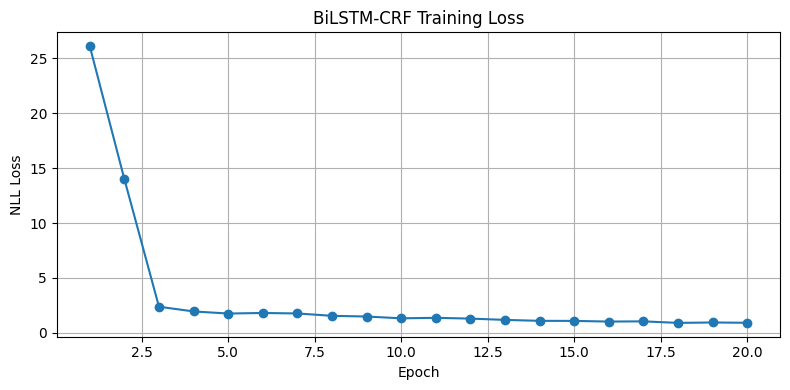

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM  = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT    = 0.3
EPOCHS     = 20
LR         = 1e-3

model = BiLSTM_CRF(
    vocab_size=len(word2idx),
    tagset_size=len(tag2idx),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_tag_idx=tag2idx["PAD"]
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses = []

if len(train_loader) == 0:
    print("train_loader is empty. Fix dataset first.")
else:
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for x_batch, y_batch, mask_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)

            optimizer.zero_grad()
            loss = model(x_batch, y_batch, mask_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step()

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}")

    print("Training complete. Logged losses:", len(train_losses))

    if len(train_losses) > 0:
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
        plt.title("BiLSTM-CRF Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("NLL Loss")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No losses recorded. Something went wrong in training.")

In [24]:
torch.save(model.state_dict(), "bilstm_crf_ayurveda.pt")
print(" BiLSTM-CRF model saved to bilstm_crf_ayurveda.pt")
 

 BiLSTM-CRF model saved to bilstm_crf_ayurveda.pt


In [27]:
from collections import defaultdict

def evaluate_model(model, loader, idx2tag, pad_tag_idx, device):
    model.eval()
    true_all, pred_all = [], []

    with torch.no_grad():
        for x_batch, y_batch, mask_batch in loader:
            x_batch    = x_batch.to(device)
            mask_batch = mask_batch.to(device)
            preds      = model.predict(x_batch, mask_batch)

            for i in range(len(y_batch)):
                length = mask_batch[i].sum().item()
                true_tags = [idx2tag[t.item()] for t in y_batch[i, :length]]
                pred_tags = [idx2tag[t.item()] for t in preds[i, :length]]
                true_all.append(true_tags)
                pred_all.append(pred_tags)

    return true_all, pred_all


def compute_metrics(true_all, pred_all, tag2idx):
    def get_entities(seq):
        entities = set()
        start, label = None, None
        for i, tag in enumerate(seq):
            if tag.startswith("B-"):
                if start is not None:
                    entities.add((start, i, label))
                start, label = i, tag[2:]
            elif tag.startswith("I-") and start is not None:
                if tag[2:] != label:
                    entities.add((start, i, label))
                    start, label = None, None
            else:
                if start is not None:
                    entities.add((start, i, label))
                    start, label = None, None
        if start is not None:
            entities.add((start, len(seq), label))
        return entities

    tp = defaultdict(int)
    fp = defaultdict(int)
    fn = defaultdict(int)

    correct_tokens = 0
    total_tokens = 0

    for true_seq, pred_seq in zip(true_all, pred_all):
        true_ents = get_entities(true_seq)
        pred_ents = get_entities(pred_seq)

        for ent in pred_ents:
            if ent in true_ents:
                tp[ent[2]] += 1
            else:
                fp[ent[2]] += 1

        for ent in true_ents:
            if ent not in pred_ents:
                fn[ent[2]] += 1

        for t, p in zip(true_seq, pred_seq):
            if t == p:
                correct_tokens += 1
            total_tokens += 1

    all_labels = set(list(tp.keys()) + list(fp.keys()) + list(fn.keys()))
    results = {}

    for label in sorted(all_labels):
        p = tp[label] / (tp[label] + fp[label] + 1e-9)
        r = tp[label] / (tp[label] + fn[label] + 1e-9)
        f = 2*p*r / (p + r + 1e-9)
        acc = correct_tokens / (total_tokens + 1e-9)

        results[label] = {
            "precision": round(p,4),
            "recall": round(r,4),
            "f1": round(f,4),
            "accuracy": round(acc,4)
        }

    total_tp = sum(tp.values())
    total_fp = sum(fp.values())
    total_fn = sum(fn.values())

    p_micro = total_tp / (total_tp + total_fp + 1e-9)
    r_micro = total_tp / (total_tp + total_fn + 1e-9)
    f_micro = 2*p_micro*r_micro / (p_micro + r_micro + 1e-9)
    acc_micro = correct_tokens / (total_tokens + 1e-9)

    results["MICRO_AVG"] = {
        "precision": round(p_micro,4),
        "recall": round(r_micro,4),
        "f1": round(f_micro,4),
        "accuracy": round(acc_micro,4)
    }

    return results


true_all, pred_all = evaluate_model(model, test_loader, idx2tag, tag2idx["PAD"], DEVICE)
metrics_bilstm = compute_metrics(true_all, pred_all, tag2idx)

print("\nBiLSTM-CRF Evaluation Results:")
print(f"{'Entity':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Accuracy':>10}")
print("-" * 60)

for label, scores in metrics_bilstm.items():
    print(f"{label:<15} {scores['precision']:>10.4f} {scores['recall']:>10.4f} {scores['f1']:>10.4f} {scores['accuracy']:>10.4f}")


BiLSTM-CRF Evaluation Results:
Entity           Precision     Recall         F1   Accuracy
------------------------------------------------------------
SYMPTOM             1.0000     0.2917     0.4516     0.9823
MICRO_AVG           1.0000     0.2917     0.4516     0.9823


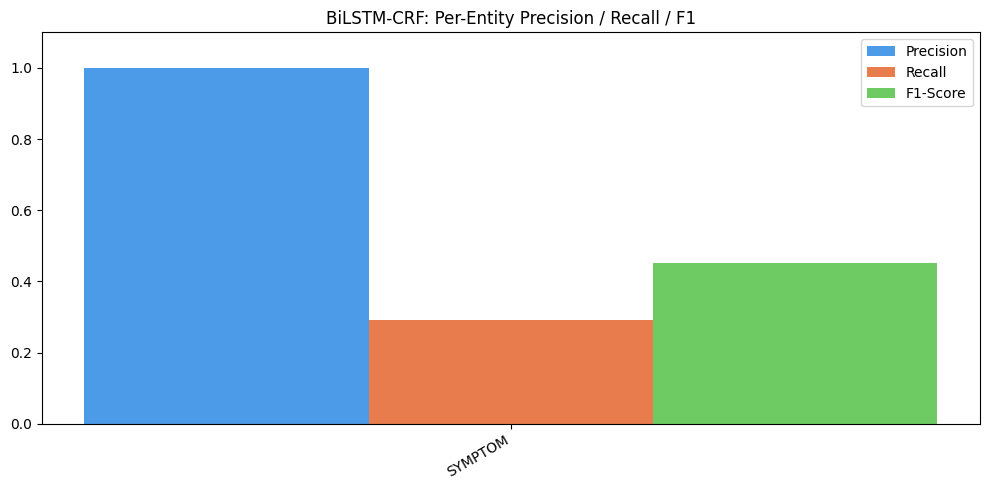

In [28]:
import matplotlib.pyplot as plt
import numpy as np
 
labels  = [k for k in metrics_bilstm.keys() if k != "MICRO_AVG"]
prec    = [metrics_bilstm[k]["precision"] for k in labels]
rec     = [metrics_bilstm[k]["recall"]    for k in labels]
f1      = [metrics_bilstm[k]["f1"]        for k in labels]
 
x = np.arange(len(labels))
w = 0.25
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, prec, w, label="Precision", color="#4C9BE8")
ax.bar(x,     rec,  w, label="Recall",    color="#E87C4C")
ax.bar(x + w, f1,   w, label="F1-Score",  color="#6ECB63")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("BiLSTM-CRF: Per-Entity Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
import torch
import torch.nn as nn
import math
 
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                          
        self.register_buffer("pe", pe)
 
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)
 
 
class TransformerNER(nn.Module):
    def __init__(self, vocab_size, num_tags, d_model=128,
                 nhead=4, num_layers=3, ff_dim=256, dropout=0.1,
                 pad_idx=0):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)
 
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc         = nn.Linear(d_model, num_tags)
 
    def forward(self, x, mask=None):

        src_key_padding_mask = ~mask if mask is not None else None
        emb  = self.pos_enc(self.embedding(x))
        enc  = self.encoder(emb, src_key_padding_mask=src_key_padding_mask)
        return self.fc(enc)
 
 
print(" Transformer NER model defined ")
 

 Transformer NER model defined 


Epoch 005/20 | Loss: 0.0344
Epoch 010/20 | Loss: 0.0183
Epoch 015/20 | Loss: 0.0116
Epoch 020/20 | Loss: 0.0113


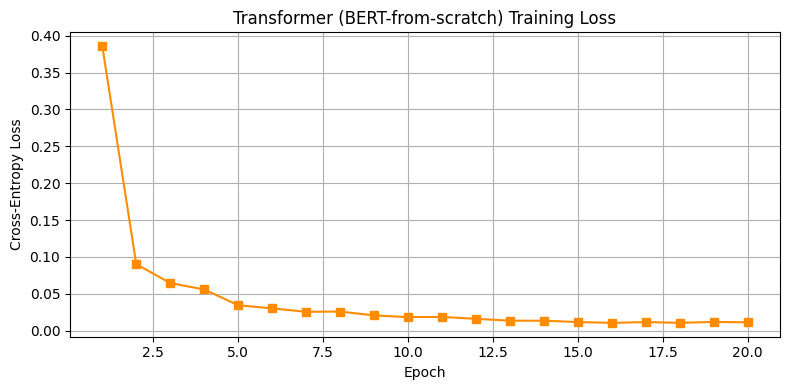

 Transformer NER model saved to transformer_ner_ayurveda.pt


In [30]:
import torch.optim as optim
 
BERT_EPOCHS = 20
BERT_LR     = 5e-4
 
bert_model = TransformerNER(
    vocab_size = len(word2idx),
    num_tags   = len(tag2idx),
    d_model    = 128,
    nhead      = 4,
    num_layers = 3,
    ff_dim     = 256,
    dropout    = 0.1,
    pad_idx    = word2idx["<PAD>"]
).to(DEVICE)
 
optimizer_bert = optim.AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=1e-4)
scheduler_bert = optim.lr_scheduler.CosineAnnealingLR(optimizer_bert, T_max=BERT_EPOCHS)
criterion      = nn.CrossEntropyLoss(ignore_index=tag2idx["PAD"])
 
bert_losses = []
 
for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss = 0
    for x_batch, y_batch, mask_batch in train_loader:
        x_batch    = x_batch.to(DEVICE)
        y_batch    = y_batch.to(DEVICE)
        mask_batch = mask_batch.to(DEVICE)
 
        optimizer_bert.zero_grad()
        logits = bert_model(x_batch, mask_batch)    # (B, T, num_tags)
        loss   = criterion(
            logits.view(-1, len(tag2idx)),
            y_batch.view(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer_bert.step()
        total_loss += loss.item()
 
    avg = total_loss / len(train_loader)
    bert_losses.append(avg)
    scheduler_bert.step()
 
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{BERT_EPOCHS} | Loss: {avg:.4f}")
 

plt.figure(figsize=(8, 4))
plt.plot(range(1, BERT_EPOCHS+1), bert_losses, marker='s', color='darkorange')
plt.title("Transformer (BERT-from-scratch) Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss")
plt.grid(True); plt.tight_layout(); plt.show()
 
torch.save(bert_model.state_dict(), "transformer_ner_ayurveda.pt")
print(" Transformer NER model saved to transformer_ner_ayurveda.pt")
 

In [32]:
from collections import defaultdict

def compute_metrics_with_accuracy(true_all, pred_all):
    def get_entities(seq):
        entities = set()
        start, label = None, None
        for i, tag in enumerate(seq):
            if tag.startswith("B-"):
                if start is not None:
                    entities.add((start, i, label))
                start, label = i, tag[2:]
            elif tag.startswith("I-") and start is not None:
                if tag[2:] != label:
                    entities.add((start, i, label))
                    start, label = None, None
            else:
                if start is not None:
                    entities.add((start, i, label))
                    start, label = None, None
        if start is not None:
            entities.add((start, len(seq), label))
        return entities

    tp, fp, fn = defaultdict(int), defaultdict(int), defaultdict(int)
    correct_tokens, total_tokens = 0, 0

    for true_seq, pred_seq in zip(true_all, pred_all):
        true_ents = get_entities(true_seq)
        pred_ents = get_entities(pred_seq)

        for ent in pred_ents:
            if ent in true_ents:
                tp[ent[2]] += 1
            else:
                fp[ent[2]] += 1

        for ent in true_ents:
            if ent not in pred_ents:
                fn[ent[2]] += 1

        for t, p in zip(true_seq, pred_seq):
            if t == p:
                correct_tokens += 1
            total_tokens += 1

    results = {}
    labels = set(tp) | set(fp) | set(fn)

    for label in sorted(labels):
        p = tp[label] / (tp[label] + fp[label] + 1e-9)
        r = tp[label] / (tp[label] + fn[label] + 1e-9)
        f = 2*p*r / (p + r + 1e-9)
        acc = correct_tokens / (total_tokens + 1e-9)

        results[label] = {
            "precision": round(p,4),
            "recall": round(r,4),
            "f1": round(f,4),
            "accuracy": round(acc,4)
        }

    total_tp = sum(tp.values())
    total_fp = sum(fp.values())
    total_fn = sum(fn.values())

    p_micro = total_tp / (total_tp + total_fp + 1e-9)
    r_micro = total_tp / (total_tp + total_fn + 1e-9)
    f_micro = 2*p_micro*r_micro / (p_micro + r_micro + 1e-9)
    acc_micro = correct_tokens / (total_tokens + 1e-9)

    results["MICRO_AVG"] = {
        "precision": round(p_micro,4),
        "recall": round(r_micro,4),
        "f1": round(f_micro,4),
        "accuracy": round(acc_micro,4)
    }

    return results


true_bert, pred_bert = evaluate_transformer(
    bert_model, test_loader, idx2tag, tag2idx["PAD"], DEVICE
)

metrics_bert = compute_metrics_with_accuracy(true_bert, pred_bert)

print("\nTransformer NER Evaluation Results:")
print(f"{'Entity':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Accuracy':>10}")
print("-" * 60)

for label, scores in metrics_bert.items():
    print(f"{label:<15} {scores['precision']:>10.4f} {scores['recall']:>10.4f} {scores['f1']:>10.4f} {scores['accuracy']:>10.4f}")


Transformer NER Evaluation Results:
Entity           Precision     Recall         F1   Accuracy
------------------------------------------------------------
SYMPTOM             0.8750     0.8750     0.8750     0.9927
MICRO_AVG           0.8750     0.8750     0.8750     0.9927


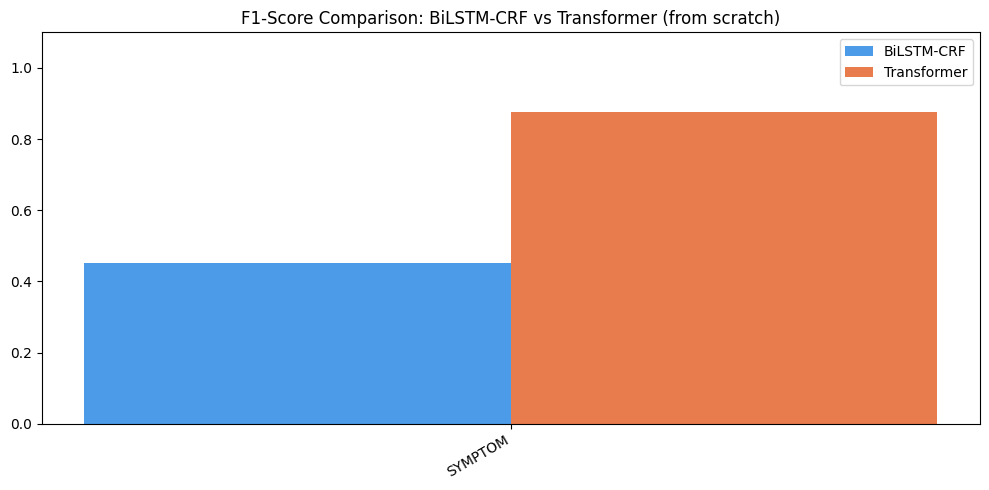

   Entity  BiLSTM-CRF P  BiLSTM-CRF R  BiLSTM-CRF F1  Transformer P  Transformer R  Transformer F1
  SYMPTOM           1.0        0.2917         0.4516          0.875          0.875           0.875
MICRO_AVG           1.0        0.2917         0.4516          0.875          0.875           0.875


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
entity_labels = [k for k in metrics_bilstm.keys() if k != "MICRO_AVG"]
 
bilstm_f1 = [metrics_bilstm[k]["f1"] for k in entity_labels]
bert_f1   = [metrics_bert[k]["f1"]   for k in entity_labels]
 
x = np.arange(len(entity_labels))
w = 0.35
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, bilstm_f1, w, label="BiLSTM-CRF",  color="#4C9BE8")
ax.bar(x + w/2, bert_f1,   w, label="Transformer",  color="#E87C4C")
ax.set_xticks(x)
ax.set_xticklabels(entity_labels, rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("F1-Score Comparison: BiLSTM-CRF vs Transformer (from scratch)")
ax.legend()
plt.tight_layout()
plt.show()
 
# Summary table
summary = []
for k in metrics_bilstm:
    summary.append({
        "Entity": k,
        "BiLSTM-CRF P": metrics_bilstm[k]["precision"],
        "BiLSTM-CRF R": metrics_bilstm[k]["recall"],
        "BiLSTM-CRF F1": metrics_bilstm[k]["f1"],
        "Transformer P": metrics_bert.get(k, {}).get("precision", 0),
        "Transformer R": metrics_bert.get(k, {}).get("recall", 0),
        "Transformer F1": metrics_bert.get(k, {}).get("f1", 0),
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

In [35]:
import pandas as pd
 
df = pd.read_csv("AyurGenixAI_Dataset.csv")
 
# ── Rule-based relation extractor ────────────────────────────
def extract_relations(text, dosha_col="Dosha", proc_col="Panchakarma"):

    relations = []
    text_lower = text.lower()
 
    # Symptom → indicates → Disease
    for sym in SYMPTOM_TERMS:
        if sym in text_lower:
            for dis in DISEASE_TERMS:
                if dis in text_lower:
                    relations.append((sym, "indicates", dis))
 
    # Medicine → treats → Disease
    for med in MEDICINE_TERMS:
        if med in text_lower:
            for dis in DISEASE_TERMS:
                if dis in text_lower:
                    relations.append((med, "treats", dis))
 
    # Dosha → imbalance → Disease
    for dos in DOSHA_TERMS:
        if dos in text_lower:
            for dis in DISEASE_TERMS:
                if dis in text_lower:
                    relations.append((dos, "imbalance_causes", dis))
 
    # Disease → requires → Procedure
    for dis in DISEASE_TERMS:
        if dis in text_lower:
            for proc in PROCEDURE_TERMS:
                if proc in text_lower:
                    relations.append((dis, "requires", proc))
 
    return relations
 
 
# ── Build relation triples from full dataset ──────────────────
all_relations = []
 
for _, row in df.iterrows():
    parts = [
        str(row.get("Symptoms", "")),
        str(row.get("Disease", "")),
        str(row.get("Treatment", "")),
        str(row.get("Dosha", "")),
        str(row.get("Panchakarma", row.get("Procedure", "")))
    ]
    combined = " ".join(parts)
    rels = extract_relations(combined)
    all_relations.extend(rels)
 
# Deduplicate
all_relations = list(set(all_relations))
 
print(f" Extracted {len(all_relations)} unique relation triples")
print("\nSample relations:")
for r in all_relations[:10]:
    print(f"  ({r[0]})  ── {r[1]} ––  ({r[2]})")

 Extracted 64 unique relation triples

Sample relations:
  (fever)  ── indicates ––  (tuberculosis)
  (nausea)  ── indicates ––  (diarrhea)
  (fever)  ── indicates ––  (fever)
  (weight loss)  ── indicates ––  (diarrhea)
  (redness)  ── indicates ––  (fever)
  (cough)  ── indicates ––  (asthma)
  (headache)  ── indicates ––  (jaundice)
  (nausea)  ── indicates ––  (jaundice)
  (skin rash)  ── indicates ––  (diarrhea)
  (weight loss)  ── indicates ––  (cough)


Knowledge Graph: 30 nodes, 64 edges


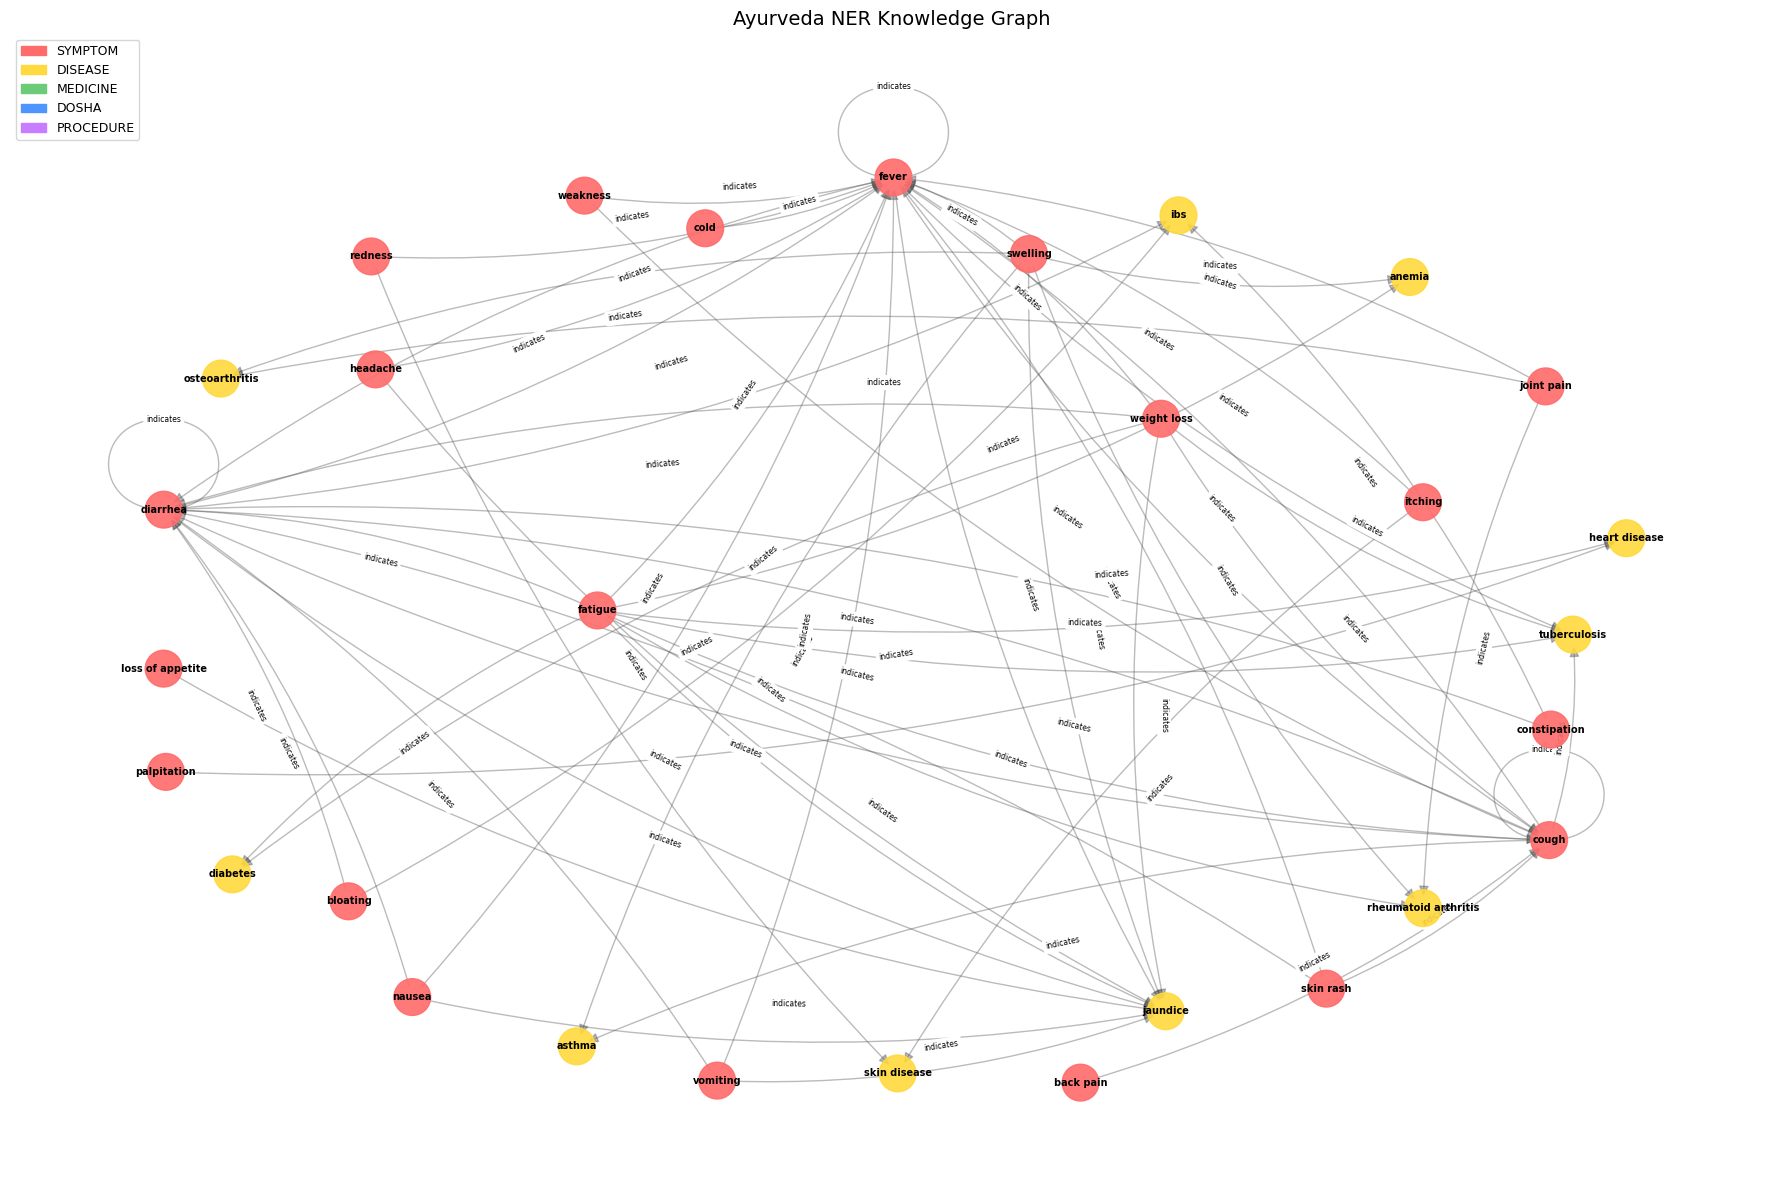

 Knowledge Graph saved to ayurveda_knowledge_graph.gexf


In [36]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
KG = nx.DiGraph()
 
# Node type colors
NODE_COLORS = {
    "SYMPTOM":   "#FF6B6B",
    "DISEASE":   "#FFD93D",
    "MEDICINE":  "#6BCB77",
    "DOSHA":     "#4D96FF",
    "PROCEDURE": "#C77DFF",
}
 
ENTITY_TYPE_MAP = {}
 
def classify_node(name):
    if name in SYMPTOM_TERMS:   return "SYMPTOM"
    if name in DISEASE_TERMS:   return "DISEASE"
    if name in MEDICINE_TERMS:  return "MEDICINE"
    if name in DOSHA_TERMS:     return "DOSHA"
    if name in PROCEDURE_TERMS: return "PROCEDURE"
    return "OTHER"
 
# Add all triples to graph
for subj, rel, obj_ in all_relations:
    KG.add_node(subj, entity_type=classify_node(subj))
    KG.add_node(obj_, entity_type=classify_node(obj_))
    KG.add_edge(subj, obj_, relation=rel)
 
print(f"Knowledge Graph: {KG.number_of_nodes()} nodes, {KG.number_of_edges()} edges")
 
# ── Visualize top-N nodes by degree ──────────────────────────
top_nodes = sorted(KG.degree, key=lambda x: x[1], reverse=True)[:40]
top_node_set = {n for n, _ in top_nodes}
subgraph = KG.subgraph(top_node_set)
 
node_colors_list = [
    NODE_COLORS.get(KG.nodes[n].get("entity_type", "OTHER"), "#AAAAAA")
    for n in subgraph.nodes
]
 
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(subgraph, k=2.5, seed=42)
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors_list,
                       node_size=700, alpha=0.9)
nx.draw_networkx_labels(subgraph, pos, font_size=7, font_weight="bold")
nx.draw_networkx_edges(subgraph, pos, alpha=0.4, arrows=True,
                       arrowsize=15, edge_color="#555555",
                       connectionstyle="arc3,rad=0.1")
 
edge_labels = {(u, v): d["relation"] for u, v, d in subgraph.edges(data=True)}
nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=5.5)
 
legend_patches = [mpatches.Patch(color=c, label=k) for k, c in NODE_COLORS.items()]
plt.legend(handles=legend_patches, loc="upper left", fontsize=9)
plt.title("Ayurveda NER Knowledge Graph ", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()
 
# Save graph
nx.write_gexf(KG, "ayurveda_knowledge_graph.gexf")
print(" Knowledge Graph saved to ayurveda_knowledge_graph.gexf")
 

In [38]:
from collections import Counter
 
print("Knowledge Graph Statistics \n")
 
# Node type distribution
type_counts = Counter(data["entity_type"] for _, data in KG.nodes(data=True))
print("Node types:")
for t, c in type_counts.items():
    print(f"  {t:<12}: {c}")
 
# Relation type distribution
rel_counts = Counter(data["relation"] for _, _, data in KG.edges(data=True))
print("\nRelation types:")
for r, c in rel_counts.items():
    print(f"  {r:<25}: {c}")
 
# Most connected nodes
print("\nTop 10 most connected nodes:")
for node, deg in sorted(KG.degree, key=lambda x: x[1], reverse=True)[:10]:
    etype = KG.nodes[node].get("entity_type", "?")
    print(f"  {node:<25} [{etype}] degree={deg}")
 

Knowledge Graph Statistics 

Node types:
  SYMPTOM     : 20
  DISEASE     : 10

Relation types:
  indicates                : 64

Top 10 most connected nodes:
  fever                     [SYMPTOM] degree=20
  diarrhea                  [SYMPTOM] degree=15
  cough                     [SYMPTOM] degree=13
  jaundice                  [DISEASE] degree=9
  fatigue                   [SYMPTOM] degree=9
  weight loss               [SYMPTOM] degree=6
  swelling                  [SYMPTOM] degree=6
  tuberculosis              [DISEASE] degree=4
  nausea                    [SYMPTOM] degree=3
  skin rash                 [SYMPTOM] degree=3


In [39]:
import pandas as pd
import json
import re
 
df = pd.read_csv("AyurGenixAI_Dataset.csv")
 
ENTITY_DICT = {
    "DOSHA": [
        "vata", "pitta", "kapha", "tridosha", "vata dosha", "pitta dosha",
        "kapha dosha", "vata-pitta", "pitta-kapha", "vata-kapha",
        "prakriti", "vikriti", "apana vata", "prana vata", "sadhaka pitta",
        "ranjaka pitta", "avalambaka kapha", "tarpaka kapha"
    ],
    "PROCEDURE": [
        "panchakarma", "vamana", "virechana", "basti", "nasya",
        "raktamokshana", "shirodhara", "abhyanga", "swedana", "udvartana",
        "pinda sweda", "kati basti", "janu basti", "greeva basti",
        "navarakizhi", "elakizhi", "pizhichil", "thalapothichil",
        "dhara", "thakradhara", "netradhara", "karnapoorna"
    ],
    "MEDICINE": [
        "ashwagandha", "triphala", "brahmi", "neem", "turmeric", "ginger",
        "amla", "shatavari", "guduchi", "tulsi", "haritaki", "bibhitaki",
        "amalaki", "guggul", "shilajit", "punarnava", "manjistha",
        "licorice", "bala", "vidari", "pippali", "chitrak",
        "trikatu", "dashamoola", "chyawanprash", "mahasudarshana churna",
        "arogyavardhini vati", "kanchnar guggul", "punarnavadi mandoor",
        "saraswatarishta", "brahmi vati", "neem oil", "castor oil", "ghee",
        "sesame oil", "mustard oil", "coconut oil"
    ],
    "DISEASE": [
        "jwara", "fever", "cough", "prameha", "diabetes", "kushtha",
        "skin disease", "amavata", "rheumatoid arthritis", "sandhivata",
        "osteoarthritis", "vata roga", "hridaya roga", "heart disease",
        "pandu", "anemia", "arsha", "piles", "atisara", "diarrhea",
        "grahani", "ibs", "shwasa", "asthma", "rajayakshma", "tuberculosis",
        "visarpa", "erysipelas", "gulma", "mutrakriccha", "uti",
        "timira", "eye disease", "kamala", "jaundice", "vatarakta", "gout",
        "unmada", "depression", "epilepsy", "apasmara", "obesity",
        "sthoulya", "hypothyroidism", "hyperthyroidism"
    ],
    "SYMPTOM": [
        "fever", "headache", "nausea", "vomiting", "fatigue", "cough",
        "cold", "body pain", "joint pain", "swelling", "redness",
        "itching", "burning sensation", "weight loss", "weight gain",
        "loss of appetite", "insomnia", "anxiety", "depression",
        "palpitation", "breathlessness", "constipation", "diarrhea",
        "bloating", "indigestion", "acidity", "skin rash", "dryness",
        "oiliness", "hair fall", "back pain", "knee pain", "weakness",
        "dizziness", "numbness", "tremors", "memory loss", "chest pain",
        "abdominal pain", "inflammation", "dehydration", "pale skin",
        "dark urine", "frequent urination", "excessive thirst"
    ]
}
 
def find_entities_in_text(text, entity_dict):
    text_lower = text.lower()
    found = []
    for label, terms in entity_dict.items():
        # Sort by length descending to match longer phrases first
        for term in sorted(terms, key=len, reverse=True):
            start = 0
            while True:
                idx = text_lower.find(term, start)
                if idx == -1:
                    break
                found.append([idx, idx + len(term), label])
                start = idx + 1
    # Remove overlapping spans — keep longest
    found.sort(key=lambda x: (x[0], -(x[1] - x[0])))
    clean = []
    last_end = -1
    for span in found:
        if span[0] >= last_end:
            clean.append(span)
            last_end = span[1]
    return clean

output_records = []
 
for _, row in df.iterrows():
    symptoms = str(row.get("Symptoms", ""))
    disease  = str(row.get("Disease", ""))
    medicine = str(row.get("Treatment", row.get("Medicine", "")))
    dosha    = str(row.get("Dosha", ""))
    proc     = str(row.get("Panchakarma", row.get("Procedure", "")))
 
    if symptoms in ("nan", "Unknown", ""):
        continue
 
    text = (
        f"Patient suffers from {symptoms.lower()}. "
        f"Diagnosed with {disease.lower()}. "
        f"Dosha involved: {dosha.lower()}. "
        f"Treated with {medicine.lower()} and {proc.lower()}."
    )
 
    labels = find_entities_in_text(text, ENTITY_DICT)
 
    if labels:
        output_records.append({"text": text, "labels": labels})
 
with open("annotations_5entity.jsonl", "w") as f:
    for rec in output_records:
        f.write(json.dumps(rec) + "\n")
 
print(f" Saved {len(output_records)} annotated records → annotations_5entity.jsonl")
print(f"\nSample record:")
print(json.dumps(output_records[0], indent=2))
 

 Saved 361 annotated records → annotations_5entity.jsonl

Sample record:
{
  "text": "Patient suffers from sore throat, chest congestion. Diagnosed with cough. Dosha involved: . Treated with  and .",
  "labels": [
    [
      67,
      72,
      "DISEASE"
    ]
  ]
}


In [41]:
import sys
!{sys.executable} -m pip install spacy

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached cloudpathlib-0.23.0-py3-none-any.whl.metadata (16 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/15

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [42]:
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 9.5 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 11.9 MB/s eta 0:00:01
     --------------------- ------------------ 6.8/12.8 MB 12.3 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 12.5 MB/s eta 0:00:01
     ------------------------------------ -- 12.1/12.8 MB 12.4 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 12.2 MB/s  0:00:01
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [43]:
import spacy
print(spacy.__version__)

3.8.14


In [44]:
import json

In [45]:
import spacy
from spacy.training.example import Example
import random
 
# Load annotated data
TRAIN_DATA_5 = []
with open("annotations_5entity.jsonl") as f:
    for line in f:
        item = json.loads(line)
        TRAIN_DATA_5.append((item["text"], {"entities": item["labels"]}))
 
print(f"Total training samples: {len(TRAIN_DATA_5)}")
 
# Build new blank model
nlp5 = spacy.blank("en")
ner5 = nlp5.add_pipe("ner")
 
for label in ["SYMPTOM", "DISEASE", "MEDICINE", "DOSHA", "PROCEDURE"]:
    ner5.add_label(label)
 
# Train
optimizer5 = nlp5.begin_training()
random.seed(42)
 
for epoch in range(30):
    random.shuffle(TRAIN_DATA_5)
    losses = {}
    for text, annotations in TRAIN_DATA_5:
        try:
            doc = nlp5.make_doc(text)
            example = Example.from_dict(doc, annotations)
            nlp5.update([example], losses=losses, drop=0.3)
        except Exception:
            continue
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/30 | Loss: {losses.get('ner', 0):.4f}")
 
nlp5.to_disk("ayurveda_ner_model_5entity")
print("\n Model saved → ayurveda_ner_model_5entity/")

Total training samples: 361
Epoch 05/30 | Loss: 72.7074
Epoch 10/30 | Loss: 23.2967
Epoch 15/30 | Loss: 19.8467
Epoch 20/30 | Loss: 9.6029
Epoch 25/30 | Loss: 9.6496
Epoch 30/30 | Loss: 1.6311

 Model saved → ayurveda_ner_model_5entity/


In [46]:
from IPython.display import display, HTML
 
ENTITY_COLORS = {
    "SYMPTOM":   {"bg": "#F4A261", "text": "#fff", "border": "#E76F51"},
    "DISEASE":   {"bg": "#E9C46A", "text": "#333", "border": "#F4A261"},
    "MEDICINE":  {"bg": "#2A9D8F", "text": "#fff", "border": "#21867A"},
    "DOSHA":     {"bg": "#4895EF", "text": "#fff", "border": "#4361EE"},
    "PROCEDURE": {"bg": "#9B5DE5", "text": "#fff", "border": "#7B2FBE"},
}
 
def build_ner_html(text, nlp_model, entity_colors=ENTITY_COLORS):

    doc = nlp_model(text)
 
    # Build character-level markup
    html_parts = []
    last_end = 0
 
    for ent in doc.ents:
        # Plain text before this entity
        if ent.start_char > last_end:
            html_parts.append(text[last_end:ent.start_char])
 
        label = ent.label_
        colors = entity_colors.get(label, {"bg": "#ccc", "text": "#000", "border": "#aaa"})
 
        span = (
            f'<mark style="'
            f'background:{colors["bg"]};'
            f'color:{colors["text"]};'
            f'border:2px solid {colors["border"]};'
            f'padding:3px 8px;'
            f'border-radius:6px;'
            f'margin:0 3px;'
            f'font-weight:600;'
            f'font-size:15px;'
            f'display:inline-block;'
            f'">'
            f'{ent.text}'
            f'<sup style="'
            f'font-size:9px;'
            f'font-weight:bold;'
            f'background:{colors["border"]};'
            f'color:#fff;'
            f'padding:1px 4px;'
            f'border-radius:3px;'
            f'margin-left:4px;'
            f'vertical-align:super;'
            f'">{label[:3]}</sup>'
            f'</mark>'
        )
        html_parts.append(span)
        last_end = ent.end_char
 
    # Remaining plain text
    html_parts.append(text[last_end:])
 
    body = "".join(html_parts)
 
    # Legend bar 
    legend_items = "".join([
        f'<span style="'
        f'background:{c["bg"]};'
        f'color:{c["text"]};'
        f'border:2px solid {c["border"]};'
        f'padding:5px 14px;'
        f'border-radius:6px;'
        f'font-weight:700;'
        f'font-size:13px;'
        f'margin:4px;'
        f'display:inline-block;'
        f'letter-spacing:1px;'
        f'">{label}</span>'
        for label, c in entity_colors.items()
    ])
 
    full_html = f"""
    <div style="
        font-family: 'Segoe UI', Arial, sans-serif;
        background: #f8f9fa;
        border-radius: 12px;
        padding: 24px 28px;
        margin: 16px 0;
        box-shadow: 0 2px 12px rgba(0,0,0,0.08);
        max-width: 900px;
    ">
        <!-- Legend Row -->
        <div style="margin-bottom:18px; padding-bottom:14px;
                    border-bottom:2px solid #e0e0e0;">
            {legend_items}
        </div>
        <!-- Annotated Text -->
        <div style="
            line-height: 2.8;
            font-size: 16px;
            color: #222;
            letter-spacing: 0.2px;
        ">
            {body}
        </div>
    </div>
    """
    return full_html
 
 
def show_ner(text, nlp_model=None):

    if nlp_model is None:
        nlp_model = nlp5
    html = build_ner_html(text, nlp_model)
    display(HTML(html))
 
 
print("=" * 60)
print("NER VISUALIZATION — AYURVEDA ENTITIES")
print("=" * 60)
 
sentences = [
    "Patient suffers from fever, headache and joint pain, diagnosed with amavata. Pitta dosha is imbalanced. Treated with guggul and virechana.",
    "Kapha dosha causes weight gain, fatigue and bloating. Ashwagandha and triphala are prescribed. Panchakarma therapy is recommended.",
    "Vata dosha imbalance leads to insomnia, back pain and anxiety. Brahmi and shirodhara are used for treatment.",
    "Symptoms include breathlessness and chest pain. Shwasa is diagnosed. Pippali and nasya procedure are advised.",
    "Patient has skin rash, itching and redness due to kushtha. Neem oil and basti treatment are prescribed with swedana.",
]
 
for sent in sentences:
    show_ner(sent)

NER VISUALIZATION — AYURVEDA ENTITIES


In [47]:
from spacy import displacy
 
DISPLACY_COLORS = {
    "SYMPTOM":   "#F4A261",
    "DISEASE":   "#E9C46A",
    "MEDICINE":  "#2A9D8F",
    "DOSHA":     "#4895EF",
    "PROCEDURE": "#9B5DE5",
}
 
OPTIONS = {"colors": DISPLACY_COLORS, "ents": list(DISPLACY_COLORS.keys())}

for sent in sentences:
    doc = nlp5(sent)
    displacy.render(doc, style="ent", jupyter=True, options=OPTIONS)
    print() 

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import random
 
def char_to_bio(text, labels):
    tokens = text.split()
    token_spans = []
    offset = 0
    for tok in tokens:
        start = text.find(tok, offset)
        end   = start + len(tok)
        token_spans.append((start, end))
        offset = end
 
    tags = ["O"] * len(tokens)
    for span_start, span_end, label in labels:
        for i, (ts, te) in enumerate(token_spans):
            if ts >= span_start and te <= span_end:
                tags[i] = f"B-{label}" if ts == span_start else f"I-{label}"
    return tokens, tags
 
bio_data = []
with open("annotations_5entity.jsonl") as f:
    for line in f:
        item = json.loads(line)
        tokens, tags = char_to_bio(item["text"], item["labels"])
        if tokens:
            bio_data.append((tokens, tags))
 
random.seed(42)
random.shuffle(bio_data)
split    = int(0.8 * len(bio_data))
train_d  = bio_data[:split]
test_d   = bio_data[split:]
 

word_counter = Counter(tok for tokens, _ in bio_data for tok in tokens)
word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, _ in word_counter.most_common():
    word2idx[w] = len(word2idx)
 
all_tags = sorted({tag for _, tags in bio_data for tag in tags})
tag2idx  = {"PAD": 0}
for t in all_tags:
    tag2idx[t] = len(tag2idx)
idx2tag = {v: k for k, v in tag2idx.items()}
 
MAX_LEN = 64
 
def encode_sample(tokens, tags):
    x = [word2idx.get(t, 1) for t in tokens][:MAX_LEN]
    y = [tag2idx.get(t, 0) for t in tags][:MAX_LEN]
    pad = MAX_LEN - len(x)
    x   += [0] * pad
    y   += [0] * pad
    mask = [1] * (MAX_LEN - pad) + [0] * pad
    return x, y, mask
 
class NERDataset(Dataset):
    def __init__(self, data):
        self.samples = []
        for tokens, tags in data:
            x, y, mask = encode_sample(tokens, tags)
            self.samples.append((
                torch.tensor(x,    dtype=torch.long),
                torch.tensor(y,    dtype=torch.long),
                torch.tensor(mask, dtype=torch.bool)
            ))
    def __len__(self):       return len(self.samples)
    def __getitem__(self, i): return self.samples[i]
 
train_loader = DataLoader(NERDataset(train_d), batch_size=32, shuffle=True)
test_loader  = DataLoader(NERDataset(test_d),  batch_size=32)
 
print(f"Vocab: {len(word2idx)} | Tags: {len(tag2idx)}")
print(f"Train: {len(train_d)} | Test: {len(test_d)}")
print("Tags:", tag2idx)

Vocab: 841 | Tags: 5
Train: 288 | Test: 73
Tags: {'PAD': 0, 'B-DISEASE': 1, 'B-SYMPTOM': 2, 'I-SYMPTOM': 3, 'O': 4}


In [49]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tagset_size, embed_dim=64,
                 hidden_dim=128, num_layers=2, dropout=0.3, pad_tag=0):
        super().__init__()
        self.pad_tag     = pad_tag
        self.tagset_size = tagset_size
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm        = nn.LSTM(embed_dim, hidden_dim // 2,
                                   num_layers=num_layers, bidirectional=True,
                                   batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0)
        self.fc          = nn.Linear(hidden_dim, tagset_size)
        self.dropout     = nn.Dropout(dropout)
        self.transitions = nn.Parameter(torch.randn(tagset_size, tagset_size))
        self.transitions.data[:, pad_tag] = -10000
        self.transitions.data[pad_tag, :] = -10000
 
    def _emit(self, x):
        e = self.dropout(self.embedding(x))
        o, _ = self.lstm(e)
        return self.fc(self.dropout(o))
 
    def _forward_alg(self, emit, mask):
        B, T, K = emit.shape
        score = emit[:, 0]
        for t in range(1, T):
            m = mask[:, t].unsqueeze(1)
            ns = score.unsqueeze(2) + self.transitions.unsqueeze(0) + emit[:, t].unsqueeze(1)
            ns = torch.logsumexp(ns, dim=1)
            score = torch.where(m.bool(), ns, score)
        return torch.logsumexp(score, dim=1)
 
    def _score(self, emit, tags, mask):
        B, T, _ = emit.shape
        score = torch.zeros(B, device=emit.device)
        for t in range(T):
            m  = mask[:, t].float()
            e  = emit[:, t].gather(1, tags[:, t].unsqueeze(1)).squeeze(1)
            score += e * m
            if t > 0:
                score += self.transitions[tags[:, t], tags[:, t-1]] * m
        return score
 
    def decode(self, emit, mask):
        B, T, K = emit.shape
        vit = emit[:, 0]
        bps = []
        for t in range(1, T):
            ns = vit.unsqueeze(2) + self.transitions.unsqueeze(0)
            best_score, best_tag = ns.max(dim=1)
            bps.append(best_tag)
            m   = mask[:, t].unsqueeze(1)
            vit = torch.where(m.bool(), best_score + emit[:, t], vit)
        best = [vit.argmax(dim=1)]
        last = best[0]
        for bp in reversed(bps):
            last = bp.gather(1, last.unsqueeze(1)).squeeze(1)
            best.append(last)
        best.reverse()
        return torch.stack(best, dim=1)
 
    def forward(self, x, tags, mask):
        emit = self._emit(x)
        return (self._forward_alg(emit, mask) - self._score(emit, tags, mask)).mean()
 
    def predict(self, x, mask):
        return self.decode(self._emit(x), mask)
 
print(" BiLSTM-CRF defined")
 


 BiLSTM-CRF defined


Epoch 05/25 | Loss: 2.7972
Epoch 10/25 | Loss: 1.9753
Epoch 15/25 | Loss: 1.4134
Epoch 20/25 | Loss: 1.1045
Epoch 25/25 | Loss: 0.9656


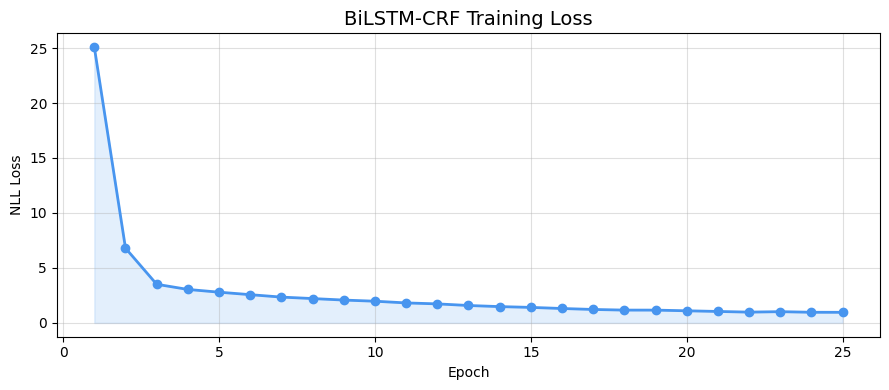

 BiLSTM-CRF saved → bilstm_crf_ayurveda.pt


In [50]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 25
 
bilstm_model = BiLSTM_CRF(
    vocab_size=len(word2idx), tagset_size=len(tag2idx),
    embed_dim=64, hidden_dim=128, num_layers=2,
    dropout=0.3, pad_tag=tag2idx["PAD"]
).to(DEVICE)
 
optimizer = optim.Adam(bilstm_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.6)
train_losses = []
 
for epoch in range(EPOCHS):
    bilstm_model.train()
    total = 0
    for xb, yb, mb in train_loader:
        xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        optimizer.zero_grad()
        loss = bilstm_model(xb, yb, mb)
        loss.backward()
        nn.utils.clip_grad_norm_(bilstm_model.parameters(), 5.0)
        optimizer.step()
        total += loss.item()
    avg = total / len(train_loader)
    train_losses.append(avg)
    scheduler.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg:.4f}")
 
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', color='#4895EF', linewidth=2)
plt.fill_between(range(1, EPOCHS+1), train_losses, alpha=0.15, color='#4895EF')
plt.title("BiLSTM-CRF Training Loss", fontsize=14)
plt.xlabel("Epoch"); plt.ylabel("NLL Loss")
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()
 
torch.save(bilstm_model.state_dict(), "bilstm_crf_ayurveda.pt")
print(" BiLSTM-CRF saved → bilstm_crf_ayurveda.pt")

In [51]:
import math
 
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
 
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])
 
class TransformerNER(nn.Module):
    def __init__(self, vocab_size, num_tags, d_model=128,
                 nhead=4, num_layers=3, ff_dim=256, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc      = nn.Linear(d_model, num_tags)
 
    def forward(self, x, mask=None):
        pad_mask = ~mask if mask is not None else None
        emb = self.pos_enc(self.embed(x))
        enc = self.encoder(emb, src_key_padding_mask=pad_mask)
        return self.fc(enc)
 
transformer_model = TransformerNER(
    vocab_size=len(word2idx), num_tags=len(tag2idx),
    d_model=128, nhead=4, num_layers=3, ff_dim=256, dropout=0.1
).to(DEVICE)
 
print(" Transformer NER defined")

 Transformer NER defined


Epoch 05/25 | Loss: 0.0432
Epoch 10/25 | Loss: 0.0257
Epoch 15/25 | Loss: 0.0166
Epoch 20/25 | Loss: 0.0144
Epoch 25/25 | Loss: 0.0131


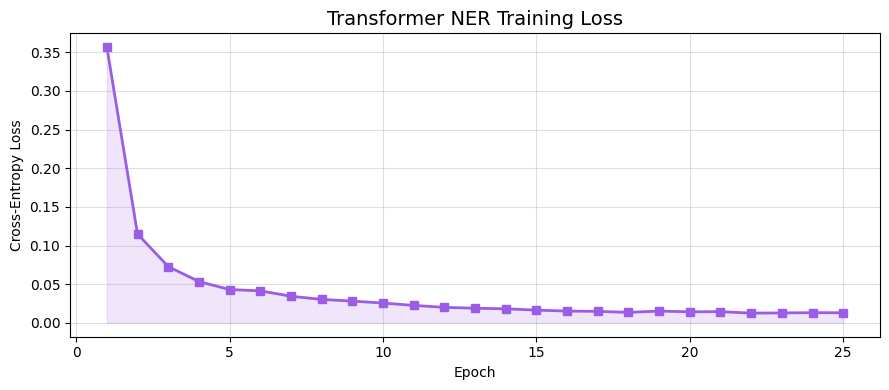

 Transformer NER saved → transformer_ner_ayurveda.pt


In [52]:
BERT_EPOCHS = 25
criterion   = nn.CrossEntropyLoss(ignore_index=tag2idx["PAD"])
opt_bert    = optim.AdamW(transformer_model.parameters(), lr=5e-4, weight_decay=1e-4)
sched_bert  = optim.lr_scheduler.CosineAnnealingLR(opt_bert, T_max=BERT_EPOCHS)
bert_losses = []
 
for epoch in range(BERT_EPOCHS):
    transformer_model.train()
    total = 0
    for xb, yb, mb in train_loader:
        xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        opt_bert.zero_grad()
        logits = transformer_model(xb, mb)
        loss   = criterion(logits.view(-1, len(tag2idx)), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        opt_bert.step()
        total += loss.item()
    avg = total / len(train_loader)
    bert_losses.append(avg)
    sched_bert.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{BERT_EPOCHS} | Loss: {avg:.4f}")
 
plt.figure(figsize=(9, 4))
plt.plot(range(1, BERT_EPOCHS+1), bert_losses, marker='s', color='#9B5DE5', linewidth=2)
plt.fill_between(range(1, BERT_EPOCHS+1), bert_losses, alpha=0.15, color='#9B5DE5')
plt.title("Transformer NER Training Loss", fontsize=14)
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()
 
torch.save(transformer_model.state_dict(), "transformer_ner_ayurveda.pt")
print(" Transformer NER saved → transformer_ner_ayurveda.pt")

In [54]:
from collections import defaultdict

def get_entities(seq):
    ents, start, label = set(), None, None
    for i, tag in enumerate(seq):
        if tag.startswith("B-"):
            if start is not None:
                ents.add((start, i, label))
            start, label = i, tag[2:]
        elif tag.startswith("I-") and start is not None and tag[2:] == label:
            pass
        else:
            if start is not None:
                ents.add((start, i, label))
            start, label = None, None
    if start is not None:
        ents.add((start, len(seq), label))
    return ents


def compute_prf(true_seqs, pred_seqs):
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)

    correct_tokens = 0
    total_tokens = 0

    for ts, ps in zip(true_seqs, pred_seqs):
        te = get_entities(ts); pe = get_entities(ps)

        for e in pe:
            (tp if e in te else fp)[e[2]] += 1
        for e in te:
            if e not in pe: fn[e[2]] += 1

        for t, p in zip(ts, ps):
            if t == p:
                correct_tokens += 1
            total_tokens += 1

    rows = {}
    acc = correct_tokens / (total_tokens + 1e-9)

    for lbl in set(list(tp) + list(fp) + list(fn)):
        p = tp[lbl] / (tp[lbl] + fp[lbl] + 1e-9)
        r = tp[lbl] / (tp[lbl] + fn[lbl] + 1e-9)
        f = 2*p*r   / (p + r + 1e-9)
        rows[lbl] = {
            "P": round(p,4),
            "R": round(r,4),
            "F1": round(f,4),
            "ACC": round(acc,4)
        }

    TP = sum(tp.values()); FP = sum(fp.values()); FN = sum(fn.values())
    pm = TP/(TP+FP+1e-9); rm = TP/(TP+FN+1e-9)
    fm = 2*pm*rm/(pm+rm+1e-9)
    acc_micro = correct_tokens / (total_tokens + 1e-9)

    rows["MICRO_AVG"] = {
        "P": round(pm,4),
        "R": round(rm,4),
        "F1": round(fm,4),
        "ACC": round(acc_micro,4)
    }

    return rows

bilstm_model.eval()
true_all_b, pred_all_b = [], []
with torch.no_grad():
    for xb, yb, mb in test_loader:
        xb, mb = xb.to(DEVICE), mb.to(DEVICE)
        preds  = bilstm_model.predict(xb, mb)
        for i in range(len(yb)):
            ln = mb[i].sum().item()
            true_all_b.append([idx2tag[t.item()] for t in yb[i, :ln]])
            pred_all_b.append([idx2tag[t.item()] for t in preds[i, :ln]])

metrics_b = compute_prf(true_all_b, pred_all_b)

transformer_model.eval()
true_all_t, pred_all_t = [], []
with torch.no_grad():
    for xb, yb, mb in test_loader:
        xb, mb = xb.to(DEVICE), mb.to(DEVICE)
        logits = transformer_model(xb, mb)
        preds  = logits.argmax(dim=-1)
        for i in range(len(yb)):
            ln = mb[i].sum().item()
            true_all_t.append([idx2tag[t.item()] for t in yb[i, :ln]])
            pred_all_t.append([idx2tag[t.item()] for t in preds[i, :ln]])

metrics_t = compute_prf(true_all_t, pred_all_t)

print("=" * 80)
print(f"{'Entity':<14} | {'BiLSTM-CRF':^36} | {'Transformer':^26}")
print(f"{'':14} | {'P':>8} {'R':>8} {'F1':>8} {'ACC':>8} | {'P':>6} {'R':>6} {'F1':>6} {'ACC':>6}")
print("-" * 80)

for lbl in list(metrics_b.keys()):
    b = metrics_b.get(lbl, {"P":0,"R":0,"F1":0,"ACC":0})
    t = metrics_t.get(lbl, {"P":0,"R":0,"F1":0,"ACC":0})

    print(f"{lbl:<14} | {b['P']:>8.4f} {b['R']:>8.4f} {b['F1']:>8.4f} {b['ACC']:>8.4f} |"
          f" {t['P']:>6.4f} {t['R']:>6.4f} {t['F1']:>6.4f} {t['ACC']:>6.4f}")

print("=" * 80)

Entity         |              BiLSTM-CRF              |        Transformer        
               |        P        R       F1      ACC |      P      R     F1    ACC
--------------------------------------------------------------------------------
SYMPTOM        |   0.9333   0.6667   0.7778   0.9886 | 0.8864 0.9286 0.9070 0.9943
MICRO_AVG      |   0.9333   0.6667   0.7778   0.9886 | 0.8864 0.9286 0.9070 0.9943


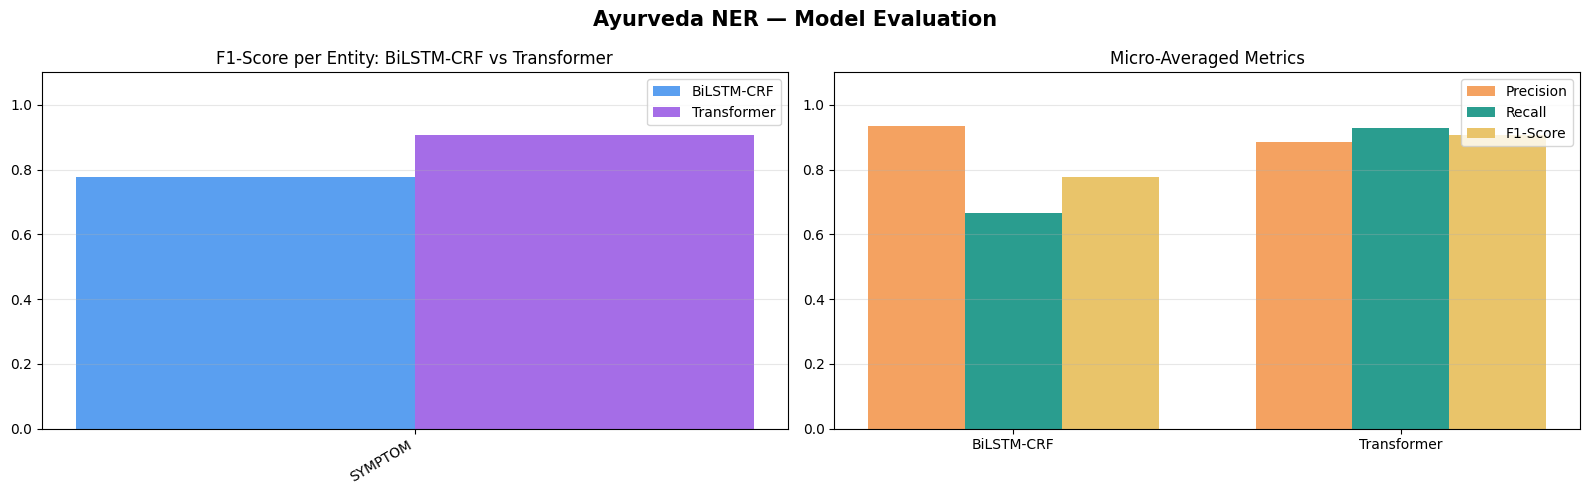

In [55]:
import numpy as np
 
entity_keys = [k for k in metrics_b if k != "MICRO_AVG"]
bilstm_f1   = [metrics_b[k]["F1"] for k in entity_keys]
bert_f1     = [metrics_t.get(k, {"F1":0})["F1"] for k in entity_keys]
 
x = np.arange(len(entity_keys))
w = 0.35
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# F1 comparison
axes[0].bar(x - w/2, bilstm_f1, w, label="BiLSTM-CRF",  color="#4895EF", alpha=0.9)
axes[0].bar(x + w/2, bert_f1,   w, label="Transformer",  color="#9B5DE5", alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(entity_keys, rotation=30, ha="right")
axes[0].set_ylim(0, 1.1); axes[0].set_title("F1-Score per Entity: BiLSTM-CRF vs Transformer")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
 
# Micro avg summary
models   = ["BiLSTM-CRF", "Transformer"]
micro_p  = [metrics_b["MICRO_AVG"]["P"],  metrics_t.get("MICRO_AVG", {"P":0})["P"]]
micro_r  = [metrics_b["MICRO_AVG"]["R"],  metrics_t.get("MICRO_AVG", {"R":0})["R"]]
micro_f  = [metrics_b["MICRO_AVG"]["F1"], metrics_t.get("MICRO_AVG", {"F1":0})["F1"]]
 
xm = np.arange(len(models))
axes[1].bar(xm - 0.25, micro_p, 0.25, label="Precision", color="#F4A261")
axes[1].bar(xm,        micro_r, 0.25, label="Recall",    color="#2A9D8F")
axes[1].bar(xm + 0.25, micro_f, 0.25, label="F1-Score",  color="#E9C46A")
axes[1].set_xticks(xm); axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1); axes[1].set_title("Micro-Averaged Metrics")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
 
plt.suptitle("Ayurveda NER — Model Evaluation", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

In [56]:
import pandas as pd
df = pd.read_csv("AyurGenixAI_Dataset.csv")
 
SYMPTOM_LIST   = ENTITY_DICT["SYMPTOM"]
DISEASE_LIST   = ENTITY_DICT["DISEASE"]
MEDICINE_LIST  = ENTITY_DICT["MEDICINE"]
DOSHA_LIST     = ENTITY_DICT["DOSHA"]
PROCEDURE_LIST = ENTITY_DICT["PROCEDURE"]
 
def extract_relations(text):
    text_lower = text.lower()
    rels = []
    for sym in SYMPTOM_LIST:
        if sym in text_lower:
            for dis in DISEASE_LIST:
                if dis in text_lower:
                    rels.append((sym, "indicates", dis))
    for med in MEDICINE_LIST:
        if med in text_lower:
            for dis in DISEASE_LIST:
                if dis in text_lower:
                    rels.append((med, "treats", dis))
    for dos in DOSHA_LIST:
        if dos in text_lower:
            for dis in DISEASE_LIST:
                if dis in text_lower:
                    rels.append((dos, "imbalance_causes", dis))
    for dis in DISEASE_LIST:
        if dis in text_lower:
            for proc in PROCEDURE_LIST:
                if proc in text_lower:
                    rels.append((dis, "requires", proc))
    return rels
 
all_relations = []
for _, row in df.iterrows():
    combined = " ".join(str(row.get(c, "")) for c in
                        ["Symptoms", "Disease", "Treatment", "Dosha",
                         "Panchakarma", "Procedure"])
    all_relations.extend(extract_relations(combined))
 
all_relations = list(set(all_relations))
print(f" Extracted {len(all_relations)} unique relation triples")
print("\nSample triples:")
for r in all_relations[:8]:
    print(f"  ({r[0]})  ─── {r[1]} ──  ({r[2]})")
 
# Save to CSV
pd.DataFrame(all_relations, columns=["subject","relation","object"]
             ).to_csv("ayurveda_relation_triples.csv", index=False)
print("\n Saved → ayurveda_relation_triples.csv")
 

 Extracted 98 unique relation triples

Sample triples:
  (dark urine)  ─── indicates ──  (jaundice)
  (weight gain)  ─── indicates ──  (depression)
  (weight loss)  ─── indicates ──  (diarrhea)
  (weight loss)  ─── indicates ──  (cough)
  (weight loss)  ─── indicates ──  (jaundice)
  (fatigue)  ─── indicates ──  (cough)
  (chest pain)  ─── indicates ──  (fever)
  (loss of appetite)  ─── indicates ──  (jaundice)

 Saved → ayurveda_relation_triples.csv
